# Imports


In [56]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import spatialdata_io
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from scipy.sparse import issparse
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

# THESE ARE LOCAL PATHS FOR NOW ! 
# Base directories for the folders containing the data for the two versions of the Xenium platform
BASE_5K = Path("C://Users//ntpar//Downloads//Xenium_Prime_Human_Lung_Cancer_FFPE_xe_outs")
BASE_V1 = Path("C://Users//ntpar//Downloads//Xenium_V1_Human_Lung_Cancer_FFPE_xe_outs")

# Ovary panels
BASE_5K_Ovary = Path("C:/Users/ntpar/Downloads/Xenium_Prime_Human_Ovary_Cancer_FF_xe_outs")
BASE_V1_Ovary = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Ovary_Cancer_FF_xe_outs")

# Extra lung panel I
BASE_Lung1 = Path("C:/Users/ntpar/Downloads/Xenium_V1_Human_Lung_Cancer_Addon_FFPE_xe_outs")

# Extra lung panel II
BASE_Lung2 = Path("C:/Users/ntpar/Downloads/Xenium_V1_humanLung_Cancer_FFPE_xe_outs")

# SpatialData loading
We load the SpatialData objects, and we only want to include the cell boundaries + tables

In [57]:
# Load all panel folders as SpatialData + AnnData tables 
PANEL_BASES = {
    "5K": BASE_5K,
    "V1": BASE_V1,
    "5K_Ovary": BASE_5K_Ovary,
    "V1_Ovary": BASE_V1_Ovary,
    "Lung1": BASE_Lung1,
    "Lung2": BASE_Lung2,
}

def _load_panel(base_path):
    sdata_obj = spatialdata_io.xenium(
        base_path,
        nucleus_labels=False,
        cell_labels=False,
        morphology_mip=False,
        transcripts=False,
        morphology_focus=False,
    )
    adata_obj = sdata_obj.tables["table"]
    return sdata_obj, adata_obj

sdatas_raw = {}
adatas_raw = {}

for panel_name, panel_path in PANEL_BASES.items():
    s_obj, a_obj = _load_panel(panel_path)
    sdatas_raw[panel_name] = s_obj
    adatas_raw[panel_name] = a_obj

# aliases used later in notebook
sdata_5k_raw = sdatas_raw["5K"]
sdata_v1_raw = sdatas_raw["V1"]
adata_5k_raw = adatas_raw["5K"]
adata_v1_raw = adatas_raw["V1"]

# Working copies (will be updated by QC/filtering)
sdatas = dict(sdatas_raw)
adatas = dict(adatas_raw)
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]

print("Loaded panels:")
for panel_name, ad in adatas_raw.items():
    print(f"  {panel_name}: {ad.shape}")

C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\872385150.py:12: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_obj = spatialdata_io.xenium(
C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\872385150.py:12: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata_obj = spatialdata_io.xenium(
c:\Users\ntpar\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\872385150.py:12: DeprecationWarning: `cell_labels` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_labels` instead.
  sdata_obj = spatialdata_io.xenium(
C:\Users\ntpar\AppData\Local\Temp\ipy

Loaded panels:
  5K: (278328, 5001)
  V1: (278659, 289)
  5K_Ovary: (200900, 5001)
  V1_Ovary: (205082, 477)
  Lung1: (161000, 480)
  Lung2: (162254, 377)


In [58]:
# Quick preview 
sdatas["5K"]

SpatialData object
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (275207, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (278328, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [59]:
# Second preview (V1) + confirm dictionaries are initialized
sdatas["V1"]

print(f"Total initialized panels: {len(sdatas_raw)}")
print("Panel keys:", sorted(sdatas_raw.keys()))

Total initialized panels: 6
Panel keys: ['5K', '5K_Ovary', 'Lung1', 'Lung2', 'V1', 'V1_Ovary']


# Quality Control: Filtering cells & transcripts

### Calculating extra rows 

sc.pp.calculate_qc_metrics calculates these variables: 
- 'n_genes_by_counts',
- 'log1p_n_genes_by_counts', 
- 'total_counts', 
- 'log1p_total_counts', 
- 'pct_counts_in_top_50_genes', 
- 'pct_counts_in_top_100_genes', 
- 'pct_counts_in_top_200_genes', 
- 'pct_counts_in_top_289_genes'

In [60]:
# Compute QC metrics for every initialized panel with one shared standard
pt = tuple((50, 100, 200, 289))

for panel_name, ad in adatas_raw.items():
    if panel_name == "5K":
        sc.pp.calculate_qc_metrics(ad, inplace=True)
    else:
        sc.pp.calculate_qc_metrics(ad, inplace=True, percent_top=pt)

# Refresh working dictionaries + backward-compatible aliases
adatas = dict(adatas_raw)
sdatas = dict(sdatas_raw)
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]

print("QC metrics computed for panels:", ", ".join(sorted(adatas.keys())))
adata_5k

QC metrics computed for panels: 5K, 5K_Ovary, Lung1, Lung2, V1, V1_Ovary


AnnData object with n_obs × n_vars = 278328 × 5001
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

### Cell filtering
- We filter the cells with less than the threshold number of transcripts
- We also filter the transcripts with a QV < 20 out
    - What's nice is that these transcripts are automatically already not included in the table for the cells, so we don't have to change anything about total_counts etc.
    - The qv column in Xeniums transcript table is a Phred-scaled â€œQ-Scoreâ€ that represents confidence in each decoded transcript call. Conceptually, itâ€™s a rescaling of an estimated error probability: higher qv means higher probability that the transcript identity/call is correct

In [61]:
# SET QC METRICS HERE
threshold = 40
genes_threshold = 10

# Apply the same cell-level filtering standards to every panel
adatas_f = {}
for panel_name, ad in adatas_raw.items():
    panel_mask = (
        (ad.obs["total_counts"] >= threshold)
        & (ad.obs["n_genes_by_counts"] > genes_threshold)
    )
    adatas_f[panel_name] = ad[panel_mask].copy()

# Update SpatialData tables to filtered tables for all panels
sdatas_f = dict(sdatas_raw)
for panel_name, s_obj in sdatas_f.items():
    s_obj.tables["table"] = adatas_f[panel_name]

# Refresh working dictionaries + backward-compatible aliases
adatas = dict(adatas_f)
sdatas = dict(sdatas_f)
adata_5k = adatas["5K"]
adata_v1 = adatas["V1"]
adata_5k_f = adatas_f["5K"]
adata_v1_f = adatas_f["V1"]
sdata_5k = sdatas["5K"]
sdata_v1 = sdatas["V1"]

In [62]:
# Report filtering impact for all panels
for panel_name in sorted(adatas_raw.keys()):
    n_before = adatas_raw[panel_name].n_obs
    n_after = adatas_f[panel_name].n_obs
    n_removed = n_before - n_after
    print(f"{panel_name}: before={n_before}, after={n_after}, removed={n_removed}")

5K: before=278328, after=262733, removed=15595
5K_Ovary: before=200900, after=199245, removed=1655
Lung1: before=161000, after=146394, removed=14606
Lung2: before=162254, after=93502, removed=68752
V1: before=278659, after=188761, removed=89898
V1_Ovary: before=205082, after=199195, removed=5887


### Look at the overlapping genes between panels

In [63]:
# Use currently active panel tables (filtered if filtering cell has been run)
panel_names = sorted(adatas.keys())
gene_sets = {name: set(adatas[name].var_names.astype(str)) for name in panel_names}

overlap_genes_all_panels = sorted(set.intersection(*(gene_sets[name] for name in panel_names)))

print("Panels included:", ", ".join(panel_names))
print(f"Number of overlapping genes across ALL panels: {len(overlap_genes_all_panels)}")

# Helpful per-panel context
for name in panel_names:
    print(f"  {name}: n_genes={adatas[name].n_vars}")

# Pairwise overlap summary
pairwise_overlap_counts = pd.DataFrame(index=panel_names, columns=panel_names, dtype=int)
for a in panel_names:
    for b in panel_names:
        pairwise_overlap_counts.loc[a, b] = len(gene_sets[a].intersection(gene_sets[b]))

print(f"\nPairwise overlap counts: {pairwise_overlap_counts}")

# Keep a list of all the overlap genes
overlap_genes = overlap_genes_all_panels

Panels included: 5K, 5K_Ovary, Lung1, Lung2, V1, V1_Ovary
Number of overlapping genes across ALL panels: 82
  5K: n_genes=5001
  5K_Ovary: n_genes=5001
  Lung1: n_genes=480
  Lung2: n_genes=377
  V1: n_genes=289
  V1_Ovary: n_genes=477

Pairwise overlap counts:               5K  5K_Ovary  Lung1  Lung2     V1  V1_Ovary
5K        5001.0    5001.0  332.0  222.0  196.0     278.0
5K_Ovary  5001.0    5001.0  332.0  222.0  196.0     278.0
Lung1      332.0     332.0  480.0  198.0  143.0     216.0
Lung2      222.0     222.0  198.0  377.0  156.0     377.0
V1         196.0     196.0  143.0  156.0  289.0     166.0
V1_Ovary   278.0     278.0  216.0  377.0  166.0     477.0


## Per-gene statistics

### Genes to plot
From the `gene comparison spatialdata` we can find the biggest & smallest mean-differences in the overlap set
These are just a few example genes that wll be plotted in a few cells


In [64]:
genes_to_plot = ['EPCAM', 'MALL', 'CLDN5', 'ADAMTS1']
plot_genes = genes_to_plot

### What this plot shows
This plot compares the distribution of expression for selected genes between the **5K** panel and **V1** panel, one gene per row.

For each gene, two histograms are shown:
- **Left column (all cells)**: log1p(raw counts) across all cells, including zeros. This shows both detection frequency (how many zeros) and expression magnitude.
- **Right column (>0 only)**: log1p(raw counts) using only cells where the gene is detected (count > 0). This isolates expression strength among expressing cells.

Additional notes:
- The summary table printed below the plot reports per-gene:
  - `mean_first`, `mean_second`: mean raw counts in 5K and V1 across all cells.
  - `detect_pct_first`, `detect_pct_second`: percentage of cells with nonzero counts in 5K and V1.
- In this implementation, `first = 5K` and `second = V1`.

Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       6.0952           18.5485            44.2745
  EPCAM      1.4371       5.8802           24.0819            47.2010
  CLDN5      0.2131       0.0911           10.4376             6.2963
ADAMTS1      0.6847       0.5927           18.9942            18.2951


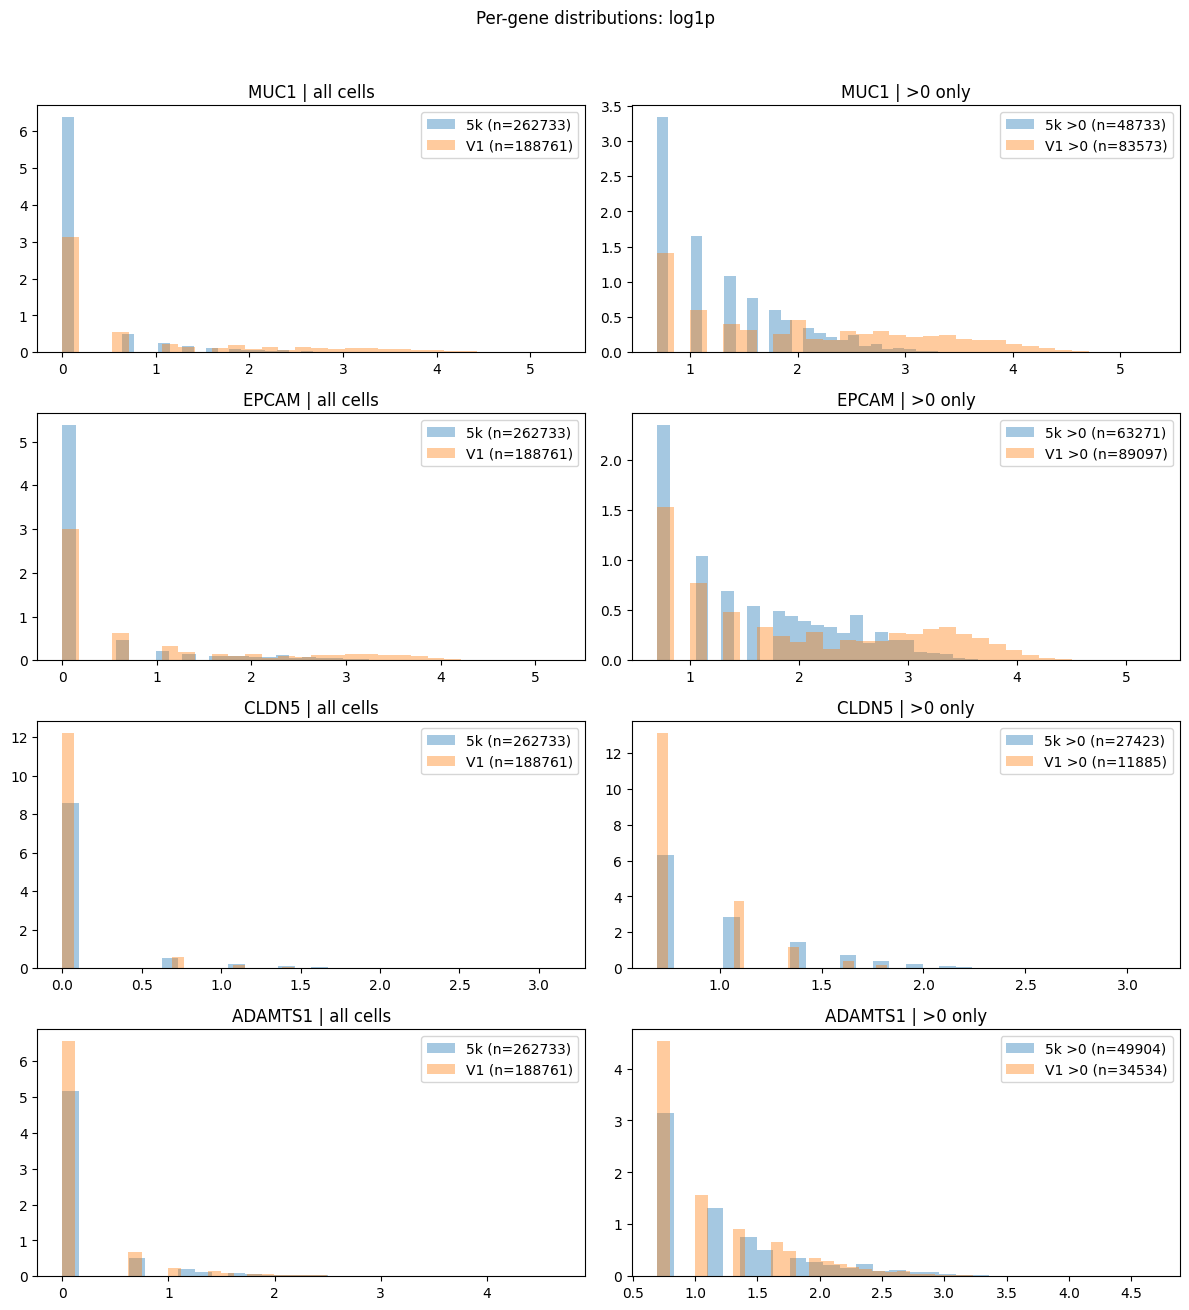

In [10]:
# This helps since we have a very sparse expression matrix, which converts it to an array
def _col_dense(X, j):
    if issparse(X):
        return X[:, j].toarray().ravel()
    return np.asarray(X)[:, j]

# Same thing but for rows
def _row_sums(X):
    if issparse(X):
        return np.ravel(X.sum(axis=1)).astype(float)
    return np.asarray(X).sum(axis=1).astype(float)

# This function will be used a lot 
def plot_gene_hist_grid(
    adata1, adata2,
    genes,
    target_sum=1e4,
    bins=30,
    seed=0,
    density=False,
    first_label="5k",
    second_label="V1",
):
    X1, X2 = adata1.X, adata2.X
    tot1, tot2 = _row_sums(X1), _row_sums(X2)

    n = len(genes)
    fig, axs = plt.subplots(n, 2, figsize=(12, 3.2 * n), squeeze=False)

    rng = np.random.default_rng(seed)
    summary_rows = []

    for i, gene in enumerate(genes):
        j1 = adata1.var_names.get_loc(gene)
        j2 = adata2.var_names.get_loc(gene)

        c1 = _col_dense(X1, j1)
        c2 = _col_dense(X2, j2)

        x1_all = np.log1p(c1)
        x2_all = np.log1p(c2)

        # >0 only
        x1_pos = x1_all[c1 > 0]
        x2_pos = x2_all[c2 > 0]

        summary_rows.append(
            {
                "gene": gene,
                "mean_first": float(np.mean(c1)),
                "mean_second": float(np.mean(c2)),
                "detect_pct_first": float(np.mean(c1 > 0) * 100),
                "detect_pct_second": float(np.mean(c2 > 0) * 100),
            }
        )

        # Left: all cells (zeros included)
        axL = axs[i, 0]
        axL.hist(x1_all, bins=bins, density=density, alpha=0.4, label=f"{first_label} (n={len(x1_all)})")
        axL.hist(x2_all, bins=bins, density=density, alpha=0.4, label=f"{second_label} (n={len(x2_all)})")
        axL.set_title(f"{gene} | all cells")
        axL.legend()

        # Right: positives only
        axR = axs[i, 1]
        axR.hist(x1_pos, bins=bins, density=density, alpha=0.4, label=f"{first_label} >0 (n={len(x1_pos)})")
        axR.hist(x2_pos, bins=bins, density=density, alpha=0.4, label=f"{second_label} >0 (n={len(x2_pos)})")
        axR.set_title(f"{gene} | >0 only")
        axR.legend()

    summary_df = pd.DataFrame(summary_rows)
    print("Per-gene summary (mean counts + detection %):")
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    fig.suptitle("Per-gene distributions: log1p", y=1.02)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_gene_hist_grid(
    adata_5k,
    adata_v1,
    genes_to_plot,
    bins=30,
    density=True,
    first_label="5k",
    second_label="V1",
)


### Downsample V1 with a fixed p 
The 5K panel is not needed for this anymore, but the value p was based on the analysis of both

In [11]:
# Use filtered cells, but keep all genes (not overlap-only)
adata_v1 = adata_v1_f.copy()
adata_5k = adata_5k_f.copy()

print("Using filtered cells with full gene sets:")
print(f"adata_v1 shape: {adata_v1.shape}")
print(f"adata_5k shape: {adata_5k.shape}")

Using filtered cells with full gene sets:
adata_v1 shape: (188761, 289)
adata_5k shape: (262733, 5001)


AnnData object with n_obs × n_vars = 188761 × 289
    obs: 'cell_id', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_289_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
Per-gene summary (mean counts + detection %):
   gene  mean_first  mean_second  detect_pct_first  detect_pct_second
   MUC1      0.7094       1.1586           18.5485            29.0478
  EPCAM      1.4371       1.1148           24.0819            29.7217
  CLDN5      0.2131       0.0173           10.4376             1.5999
ADAMTS1      0.6847       0.1129           18.9942             7.3585

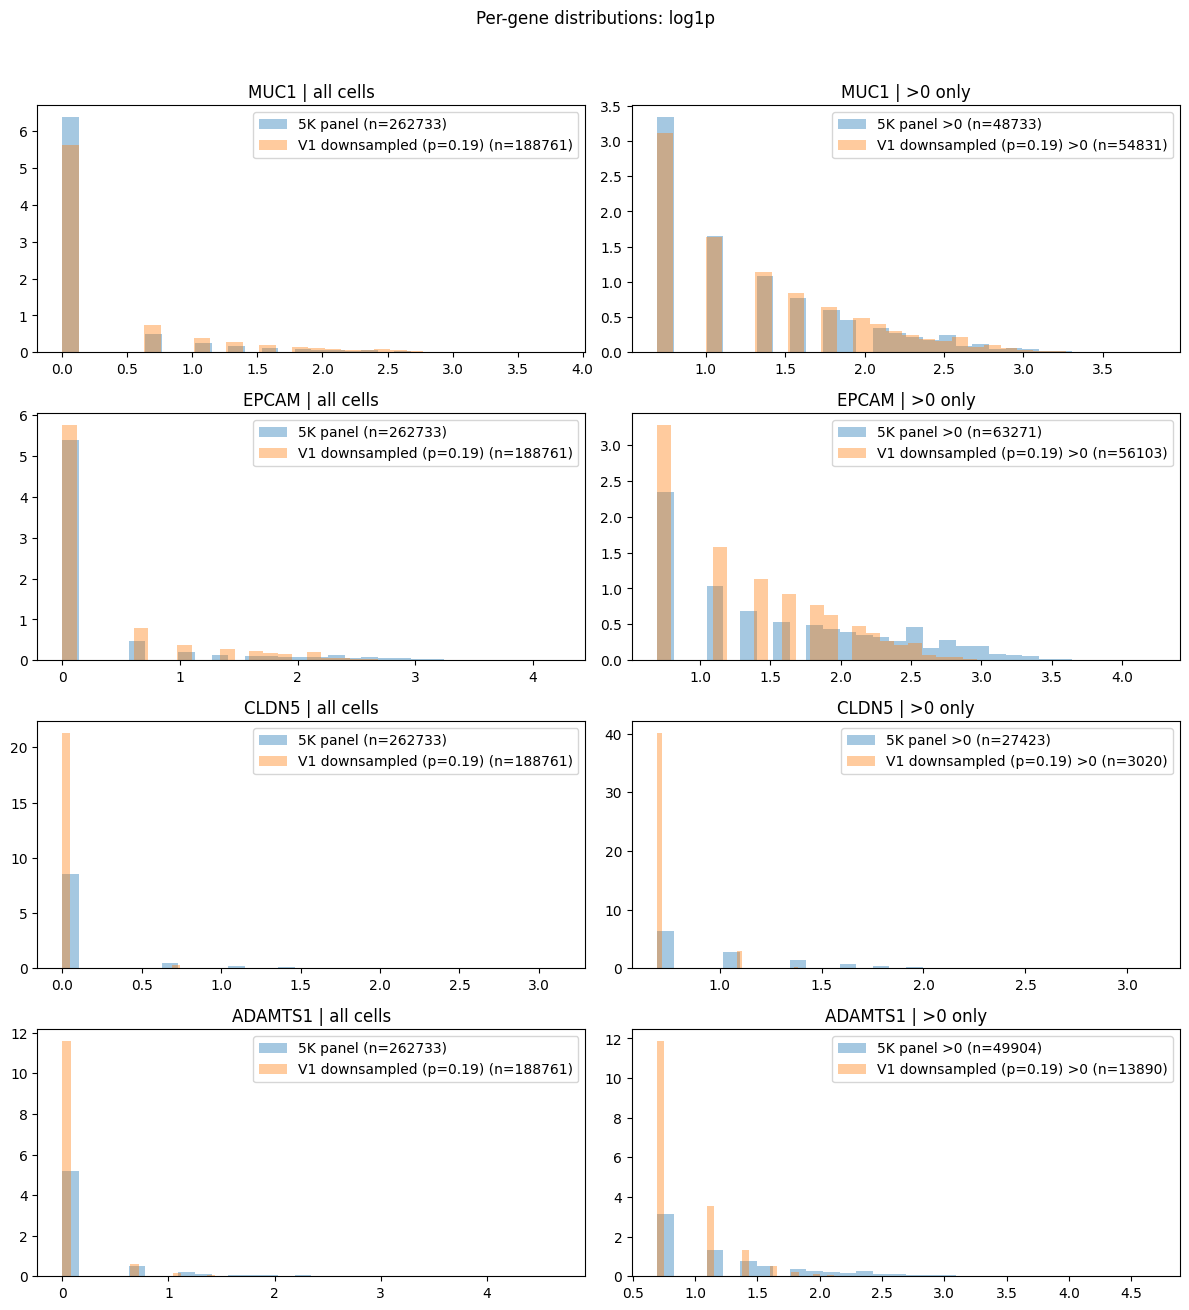

In [12]:
def downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=42,
):
    """
    Downsample V1 counts with a fixed binomial probability.
    """
    p = float(p)
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    Xv = adata_v1.X
    Xv = Xv.tocsr() if sp.issparse(Xv) else sp.csr_matrix(Xv)

    # Some sanity checks (postive & integer values)
    if Xv.data.size > 0:
        if np.any(Xv.data < 0):
            raise ValueError("adata_v1.X contains negative values")
        if np.issubdtype(Xv.data.dtype, np.floating):
            frac = np.abs(Xv.data - np.rint(Xv.data))
            if np.nanmax(frac) > 1e-6:
                raise ValueError("adata_v1.X looks non-integer (needs raw counts)")

    data_int = np.rint(Xv.data).astype(np.int64, copy=False)
    data_new = rng.binomial(data_int, p).astype(np.int64, copy=False)

    # Keep CSR structure consistent, then drop explicit zeros.
    X_new = sp.csr_matrix(
        (data_new, Xv.indices.copy(), Xv.indptr.copy()),
        shape=Xv.shape,
    )
    X_new.eliminate_zeros()

    adata_v1_ds = adata_v1.copy()
    adata_v1_ds.X = X_new
    sc.pp.calculate_qc_metrics(adata_v1_ds, inplace=True, percent_top=None)

    return adata_v1_ds


# Example usage
adata_v1_p19 = downsample_v1_fixed_p_binomial(
    adata_v1,
    p=0.19,
    seed=0,
)
print(adata_v1_p19)

plot_gene_hist_grid(
    adata_5k,
    adata_v1_p19,
    genes_to_plot,
    bins=30,
    density=True,
    first_label="5K panel",
    second_label="V1 downsampled (p=0.19)",
)

# Transformer multi-panel autoencoder

This section replaces fixed-position vectors with gene tokens so one model can train across panels with different gene sets.

#### Helper functions

In [ ]:
def _to_dense_float32(X):
    if sp.issparse(X):
        return X.toarray().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def build_gene_vocab(adatas_list):
    genes = pd.Index([])
    for adata in adatas_list:
        genes = genes.union(pd.Index(adata.var_names.astype(str)))
    genes = genes.sort_values()
    gene2id = {g: i for i, g in enumerate(genes)}
    id2gene = np.array(genes, dtype=object)
    return gene2id, id2gene

# Builds panel-specific corrupted & clean training examples (no forced shared gene space)
def make_corruptions(adata_clean, n_reps=3, p=0.19, base_seed=42):
    out = []
    for rep in range(n_reps):
        out.append(
            downsample_v1_fixed_p_binomial(
                adata_clean,
                p=p,
                seed=base_seed + rep
            )
        )
    return out

#### Setting up the panels that will be used

In [ ]:
# Panels used for tokenized training (V1-style, native genes preserved)
TRAIN_PANELS = ["V1", "Lung1", "Lung2", "V1_Ovary"]

# Adjust if metadata convention changes
PANEL_TO_TISSUE = {
    "V1": "lung",
    "Lung1": "lung",
    "Lung2": "lung",
    "V1_Ovary": "ovary",
}

# Check if there are missing panels or missing mappings 
missing_train_panels = [p for p in TRAIN_PANELS if p not in adatas]
if missing_train_panels:
    raise ValueError(f"Missing expected panels in adatas: {missing_train_panels}. Available: {sorted(adatas.keys())}")

for p in TRAIN_PANELS:
    if p not in PANEL_TO_TISSUE:
        raise ValueError(f"No tissue mapping defined for panel: {p}")

print("Tokenized training panels:", TRAIN_PANELS)
print("Tissue mapping:", PANEL_TO_TISSUE)

Tokenized training panels: ['V1', 'Lung1', 'Lung2', 'V1_Ovary']
Tissue mapping: {'V1': 'lung', 'Lung1': 'lung', 'Lung2': 'lung', 'V1_Ovary': 'ovary'}


#### Preparing the paired corrupted/downsampled - GT pairs

In [15]:
# Number of corrupted versions per panel 
N_REPS_PER_PANEL = 2

# Per-tissue corruption probabilities
P_BY_TISSUE = {
    "lung": 0.19,
    "ovary": 0.16,
}

panel2id = {p: i for i, p in enumerate(sorted(TRAIN_PANELS))}
tissue_names = sorted({PANEL_TO_TISSUE[p] for p in TRAIN_PANELS})
tissue2id = {t: i for i, t in enumerate(tissue_names)}

missing_tissues = sorted(set(PANEL_TO_TISSUE[p] for p in TRAIN_PANELS) - set(P_BY_TISSUE.keys()))
if missing_tissues:
    raise ValueError(f"Missing p values for tissues: {missing_tissues}")

# We make the paired lists of corrupted versions to their ground truth 
examples = []
for panel_name in TRAIN_PANELS:
    tissue_name = PANEL_TO_TISSUE[panel_name]
    p_panel = float(P_BY_TISSUE[tissue_name])

    y_clean = adatas[panel_name].copy()
    x_corrupt_list = make_corruptions(
        y_clean,
        n_reps=N_REPS_PER_PANEL,
        p=p_panel,
        base_seed=2000 + 97 * panel2id[panel_name],
    )
    for x_corrupt in x_corrupt_list:
        examples.append(
            {
                "panel_name": panel_name,
                "tissue_name": tissue_name,
                "panel_id": panel2id[panel_name],
                "tissue_id": tissue2id[tissue_name],
                "x_adata": x_corrupt,
                "y_adata": y_clean,
            }
        )

print(f"Constructed {len(examples)} panel-level paired examples.")
print("Panels:", panel2id)
print("Tissues:", tissue2id)
print("P by tissue:", P_BY_TISSUE)

Constructed 8 panel-level paired examples.
Panels: {'Lung1': 0, 'Lung2': 1, 'V1': 2, 'V1_Ovary': 3}
Tissues: {'lung': 0, 'ovary': 1}
P by tissue: {'lung': 0.19, 'ovary': 0.16}


#### Creating the GeneToken Dataset 
This class turns the panel-paired data into training datasets that PyTorch can use 

Each dataset item becomes one cell with
- gene_ids: The token IDs of the genes that are in the panel (so these are the same for each cell from the same panel)
- x_vals: The expression values of the corrupted/downsampled version
- y_vals: The GT expression values 
- shared_mask: For the genes that are shared across all training panels (just used for evaluation)
- tissue_ID: Integer ID of the tissue
- tissue_name: String name of the tissue 
- panel_ID: Integer ID of the tissue 
- panel_name: String name of the panel

In [16]:
# Token dataset + collate for variable-length gene sets
class GeneTokenDataset(Dataset):
    """
    One item = one cell from one panel-specific pair.
    Input tokens come from corrupted counts; target tokens from clean counts.
    """
    # We initialize with the list of paired examples and the gene2id mapping, and we pre-tokenize all cells into a list of dicts for fast __getitem__.
    def __init__(self, examples, gene2id, shared_genes):
        self.rows = []
        self.gene2id = gene2id
        shared_genes = set(map(str, shared_genes))

        for ex in examples:
            x_ad = ex["x_adata"]
            y_ad = ex["y_adata"]
            panel_name = ex["panel_name"]
            tissue_name = ex["tissue_name"]

            if x_ad.n_obs != y_ad.n_obs:
                raise ValueError(f"Cell mismatch for panel {panel_name}: {x_ad.n_obs} vs {y_ad.n_obs}")
            if not x_ad.var_names.equals(y_ad.var_names):
                raise ValueError(f"Gene order mismatch for panel {panel_name}")

            panel_genes = x_ad.var_names.astype(str).to_numpy()
            gene_ids = np.array([gene2id[g] for g in panel_genes], dtype=np.int64)
            shared_mask = np.array([g in shared_genes for g in panel_genes], dtype=bool)

            # Keep raw counts for both input and target.
            X = _to_dense_float32(x_ad.X)
            Y = _to_dense_float32(y_ad.X)
            X = np.clip(X, 0.0, None)
            Y = np.clip(Y, 0.0, None)

            for i in range(x_ad.n_obs):
                self.rows.append(
                    {
                        "gene_ids": gene_ids,
                        "x_vals": X[i],
                        "y_vals": Y[i],
                        "shared_mask": shared_mask,
                        "panel_id": int(ex["panel_id"]),
                        "tissue_id": int(ex["tissue_id"]),
                        "panel_name": panel_name,
                        "tissue_name": tissue_name,
                    }
                )

    def __len__(self):
        return len(self.rows)

    # Used to get one cell from the data 
    def __getitem__(self, idx):
        r = self.rows[idx]
        return {
            "gene_ids": torch.tensor(r["gene_ids"], dtype=torch.long),
            "x_vals": torch.tensor(r["x_vals"], dtype=torch.float32),
            "y_vals": torch.tensor(r["y_vals"], dtype=torch.float32),
            "shared_mask": torch.tensor(r["shared_mask"], dtype=torch.bool),
            "panel_id": torch.tensor(r["panel_id"], dtype=torch.long),
            "tissue_id": torch.tensor(r["tissue_id"], dtype=torch.long),
            "panel_name": r["panel_name"],
            "tissue_name": r["tissue_name"],
        }

# Needed to make padded tensors for the model, so we can handle a different number of genes per panel.
def collate_gene_tokens(batch):
    B = len(batch)
    lengths = [len(item["gene_ids"]) for item in batch]
    Lmax = max(lengths)

    gene_ids = torch.zeros(B, Lmax, dtype=torch.long)
    x_vals = torch.zeros(B, Lmax, dtype=torch.float32)
    y_vals = torch.zeros(B, Lmax, dtype=torch.float32)
    attn_mask = torch.zeros(B, Lmax, dtype=torch.bool)
    shared_mask = torch.zeros(B, Lmax, dtype=torch.bool)
    panel_ids = torch.zeros(B, dtype=torch.long)
    tissue_ids = torch.zeros(B, dtype=torch.long)
    panel_names = []
    tissue_names = []

    for i, item in enumerate(batch):
        L = len(item["gene_ids"])
        gene_ids[i, :L] = item["gene_ids"]
        x_vals[i, :L] = item["x_vals"]
        y_vals[i, :L] = item["y_vals"]
        attn_mask[i, :L] = True
        shared_mask[i, :L] = item["shared_mask"]
        panel_ids[i] = item["panel_id"]
        tissue_ids[i] = item["tissue_id"]
        panel_names.append(item["panel_name"])
        tissue_names.append(item["tissue_name"])

    return {
        "gene_ids": gene_ids,
        "x_vals": x_vals,
        "y_vals": y_vals,
        "attn_mask": attn_mask,
        "shared_mask": shared_mask,
        "panel_id": panel_ids,
        "tissue_id": tissue_ids,
        "panel_name": panel_names,
        "tissue_name": tissue_names,
    }


# Build global vocab from clean training panels
train_clean_adatas = [adatas[p] for p in TRAIN_PANELS]
gene2id, id2gene = build_gene_vocab(train_clean_adatas)

# Genes shared across all training panels (for shared vs panel-specific evaluation)
shared_train_genes = set(train_clean_adatas[0].var_names.astype(str))
for ad in train_clean_adatas[1:]:
    shared_train_genes &= set(ad.var_names.astype(str))

dataset_token = GeneTokenDataset(
    examples=examples,
    gene2id=gene2id,
    shared_genes=shared_train_genes,
 )

print(f"Token dataset cells: {len(dataset_token)}")
print(f"Vocabulary size: {len(gene2id)}")
print(f"Genes shared across training panels: {len(shared_train_genes)}")

Token dataset cells: 1255704
Vocabulary size: 827
Genes shared across training panels: 101


## GeneTokenAutoEncoder with ZINB loss reconstruction head

In [17]:
# ZINB tokenized autoencoder (Transformer encoder + gene-query decoder)

class GeneTokenAutoencoder(nn.Module):
    def __init__(
        self,
        n_genes_vocab,
        n_panels,
        n_tissues,
        d_model=128,
        nhead=4,
        num_layers=3,
        latent_dim=32,
        dropout=0.1,
        theta_init=10.0,
    ):
        super().__init__()
        # The embeddings are learned by the model, and are made to be d_model sized vectors
        self.gene_emb = nn.Embedding(n_genes_vocab, d_model)
        self.panel_emb = nn.Embedding(n_panels, d_model)
        self.tissue_emb = nn.Embedding(n_tissues, d_model)

        # The value MLP converts raw token values into d_model sized vectors for the encoder.
        self.value_mlp = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )

        # Main contextual encoder 
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # The latent bottleneck (so we have an autoencoder)
        self.latent_proj = nn.Linear(d_model, latent_dim)
        self.z_proj = nn.Linear(latent_dim, d_model)

        # Feedforward decoder, it takes the latent representatino, gene embedding and panel+tissue embedding to get ZINB parameters for each gene token 
        self.decoder_trunk = nn.Sequential(
            nn.Linear(3 * d_model, 2 * d_model),
            nn.GELU(),
            nn.Linear(2 * d_model, d_model),
            nn.GELU(),
        )
        # The output heads to get the ZINB parameters mu and pi (for now in logits) for each gene token 
        self.mu_head = nn.Linear(d_model, 1)
        self.pi_head = nn.Linear(d_model, 1)

        # Gene-specific spread parameter theta, which is learned per-gene on the entire dataset;
        theta_unconstrained_init = float(np.log(np.expm1(theta_init))) # unconstraint because not yet forced to be postive)
        self.log_theta_gene = nn.Embedding(n_genes_vocab, 1)
        nn.init.constant_(self.log_theta_gene.weight, theta_unconstrained_init)

    # This runs the input tokens through the encoder to get the latent representation z 
    def encode(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        g = self.gene_emb(gene_ids)
        x = self.value_mlp(x_vals.unsqueeze(-1))
        p = self.panel_emb(panel_id).unsqueeze(1)
        t = self.tissue_emb(tissue_id).unsqueeze(1)

        h = g + x + p + t
        pad_mask = ~attn_mask # Transformer expects True for padding positions
        h = self.encoder(h, src_key_padding_mask=pad_mask)

        mask_f = attn_mask.unsqueeze(-1).float()
        pooled = (h * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp_min(1.0) # we take the average over the gene tokens to get a single vector 
        z = self.latent_proj(pooled) 
        return z

    # This takes the latent representation z and decodes it back into ZINB parameters for each gene token
    def decode_params(self, z, gene_ids, panel_id, tissue_id):
        B, L = gene_ids.shape
        zg = self.z_proj(z).unsqueeze(1).expand(B, L, -1)
        g = self.gene_emb(gene_ids)
        p = self.panel_emb(panel_id).unsqueeze(1).expand(B, L, -1)
        t = self.tissue_emb(tissue_id).unsqueeze(1).expand(B, L, -1)

        dec_in = torch.cat([zg, g, p + t], dim=-1)
        h = self.decoder_trunk(dec_in)
        mu_logit = self.mu_head(h).squeeze(-1)
        pi_logit = self.pi_head(h).squeeze(-1)
        theta_unconstrained = self.log_theta_gene(gene_ids).squeeze(-1)
        return mu_logit, pi_logit, theta_unconstrained

    # This runs the full forward pass to get the reconstructed counts, as well as the intermediate ZINB parameters and latent representation 
    def forward_with_params(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        z = self.encode(gene_ids, x_vals, attn_mask, panel_id, tissue_id)
        mu_logit, pi_logit, theta_unconstrained = self.decode_params(z, gene_ids, panel_id, tissue_id)

        # Expected reconstructed counts under ZINB.
        mu = F.softplus(mu_logit)
        pi = torch.sigmoid(pi_logit)
        recon_counts = (1.0 - pi) * mu

        return recon_counts, z, mu_logit, pi_logit, theta_unconstrained

    # This is the simplified forward used for training and evaluation, which just returns the reconstructed counts and latent representation.
    def forward(self, gene_ids, x_vals, attn_mask, panel_id, tissue_id):
        recon_counts, z, _, _, _ = self.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )
        return recon_counts, z

# ZINB loss very similar to the VAE ZINB loss but computed at the token level, and averaged only over the valid tokens in the batch 
def token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, target_counts, attn_mask, eps=1e-8):
    target_counts = target_counts.clamp_min(0.0)

    mu = F.softplus(mu_logit) + eps
    pi = torch.sigmoid(pi_logit)
    theta = F.softplus(theta_unconstrained) + eps

    log_theta_mu = torch.log(theta + mu + eps)
    nb_log_prob = (
        torch.lgamma(target_counts + theta)
        - torch.lgamma(theta)
        - torch.lgamma(target_counts + 1.0)
        + theta * (torch.log(theta + eps) - log_theta_mu)
        + target_counts * (torch.log(mu + eps) - log_theta_mu)
    )

    zero_mask = target_counts < eps
    nb_log_prob_zero = theta * (torch.log(theta + eps) - log_theta_mu)

    zero_log_prob = torch.logaddexp(
        torch.log(pi + eps),
        torch.log1p(-pi + eps) + nb_log_prob_zero,
    )
    nonzero_log_prob = torch.log1p(-pi + eps) + nb_log_prob

    zinb_nll = -torch.where(zero_mask, zero_log_prob, nonzero_log_prob)
    return zinb_nll[attn_mask].mean()


In [ ]:
# Split + DataLoaders + training/eval helper functions
def stratified_split_indices_by_panel(dataset, seed=42):
    
    rng = np.random.default_rng(seed)

    panel_names = np.array([str(r.get("panel_name", "")) for r in dataset.rows], dtype=object)
    if np.any(panel_names == ""):
        raise ValueError("Some dataset rows are missing 'panel_name'; cannot enforce panel-only split.")

    train_panels = {"V1"}
    val_panels = {"Lung1"}
    test_panels = {"V1_Ovary", "Lung2"}
    allowed_panels = train_panels | val_panels | test_panels

    present_panels = set(np.unique(panel_names).tolist())
    unknown_panels = sorted(present_panels - allowed_panels)
    if unknown_panels:
        raise ValueError(
            f"Found panel(s) not covered by fixed split mapping: {unknown_panels}. "
            f"Allowed panels are: {sorted(allowed_panels)}"
        )

    train_idx = np.where(np.isin(panel_names, list(train_panels)))[0]
    val_idx = np.where(np.isin(panel_names, list(val_panels)))[0]
    test_idx = np.where(np.isin(panel_names, list(test_panels)))[0]

    if min(train_idx.size, val_idx.size, test_idx.size) == 0:
        raise ValueError(
            "Empty split produced with fixed panel mapping. "
            f"train={train_idx.size}, val={val_idx.size}, test={test_idx.size}"
        )

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    print("Split mode: fixed panel-only mapping")
    print(f"train panels={sorted(train_panels)} n={train_idx.size}")
    print(f"val panels={sorted(val_panels)} n={val_idx.size}")
    print(f"test panels={sorted(test_panels)} n={test_idx.size}")

    return train_idx, val_idx, test_idx


def run_epoch_token_ae(model, loader, optimizer, device, train=True, epoch_label="", log_every=200):
    model.train() if train else model.eval()

    loss_sum = 0.0
    n_batches = 0
    stage = "train" if train else "val"
    total_batches = len(loader)
    t0 = time.time()

    print(f"{epoch_label} [{stage}] starting | batches={total_batches}")

    # Keep a simple, single-line bar to avoid nested tqdm rendering issues in VS Code.
    iter_loader = tqdm(
        loader,
        desc=f"{epoch_label} [{stage}]",
        unit="batch",
        leave=True,
        position=0,
        dynamic_ncols=True,
        mininterval=0.5,
        file=sys.stdout,
    )

    for batch in iter_loader:
        batch_t0 = time.time()
        gene_ids = batch["gene_ids"].to(device)
        x_vals = batch["x_vals"].to(device)
        y_vals = batch["y_vals"].to(device)
        attn_mask = batch["attn_mask"].to(device)
        panel_id = batch["panel_id"].to(device)
        tissue_id = batch["tissue_id"].to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            _, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )
            loss = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        loss_sum += float(loss.item())
        n_batches += 1

        if n_batches == 1:
            print(f"{epoch_label} [{stage}] first batch done in {time.time() - batch_t0:.1f}s")

        if n_batches % log_every == 0 or n_batches == total_batches:
            avg_loss = loss_sum / n_batches
            elapsed = time.time() - t0
            print(
                f"{epoch_label} [{stage}] {n_batches}/{total_batches} "
                f"avg_zinb_nll={avg_loss:.5f} elapsed={elapsed/60:.1f}m"
            )
            iter_loader.set_postfix({"zinb_nll": f"{avg_loss:.5f}"})

    return loss_sum / max(n_batches, 1)


def collect_eval_rows(model, loader, device):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in tqdm(
            loader,
            desc="Token AE eval",
            unit="batch",
            leave=True,
            position=0,
            dynamic_ncols=True,
            mininterval=0.5,
            file=sys.stdout,
        ):
            gene_ids = batch["gene_ids"].to(device)
            x_vals = batch["x_vals"].to(device)
            y_vals = batch["y_vals"].to(device)
            attn_mask = batch["attn_mask"].to(device)
            shared_mask = batch["shared_mask"].to(device)
            panel_id = batch["panel_id"].to(device)
            tissue_id = batch["tissue_id"].to(device)

            recon_counts, _, mu_logit, pi_logit, theta_unconstrained = model.forward_with_params(
                gene_ids=gene_ids,
                x_vals=x_vals,
                attn_mask=attn_mask,
                panel_id=panel_id,
                tissue_id=tissue_id,
            )

            diff2 = (recon_counts - y_vals) ** 2
            zinb_nll_tok = token_zinb_loss(mu_logit, pi_logit, theta_unconstrained, y_vals, attn_mask)

            for i in range(recon_counts.shape[0]):
                valid = attn_mask[i]
                shared = valid & shared_mask[i]
                specific = valid & (~shared_mask[i])

                row = {
                    "panel_name": batch["panel_name"][i],
                    "tissue_name": batch["tissue_name"][i],
                    "mse_all": float(diff2[i][valid].mean().item()) if valid.any() else np.nan,
                    "mse_shared": float(diff2[i][shared].mean().item()) if shared.any() else np.nan,
                    "mse_specific": float(diff2[i][specific].mean().item()) if specific.any() else np.nan,
                    "zinb_nll_batch": float(zinb_nll_tok.item()),
                    "n_tokens": int(valid.sum().item()),
                    "n_shared_tokens": int(shared.sum().item()),
                    "n_specific_tokens": int(specific.sum().item()),
                }
                rows.append(row)

    return pd.DataFrame(rows)

### Training the model 

In [ ]:
# Train deterministic tokenized autoencoder (ZINB loss)

use_cuda_token = torch.cuda.is_available()
device_token = torch.device("cuda" if use_cuda_token else "cpu")
print(f"Token model device: {device_token}")

train_idx_tok, val_idx_tok, test_idx_tok = stratified_split_indices_by_panel(
    dataset_token,
    seed=42,
)

train_loader_tok = DataLoader(
    Subset(dataset_token, train_idx_tok),
    batch_size=64,
    shuffle=True,
    collate_fn=collate_gene_tokens,
)
val_loader_tok = DataLoader(
    Subset(dataset_token, val_idx_tok),
    batch_size=64,
    shuffle=False,
    collate_fn=collate_gene_tokens,
)
test_loader_tok = DataLoader(
    Subset(dataset_token, test_idx_tok),
    batch_size=64,
    shuffle=False,
    collate_fn=collate_gene_tokens,
)

print(f"train/val/test cells: {len(train_idx_tok)} / {len(val_idx_tok)} / {len(test_idx_tok)}")
print(f"train/val/test batches: {len(train_loader_tok)} / {len(val_loader_tok)} / {len(test_loader_tok)}")

model_token_ae = GeneTokenAutoencoder(
    n_genes_vocab=len(gene2id),
    n_panels=len(panel2id),
    n_tissues=len(tissue2id),
    d_model=128,
    nhead=4,
    num_layers=3,
    latent_dim=32,
    dropout=0.1,
).to(device_token)

optimizer_tok = torch.optim.Adam(model_token_ae.parameters(), lr=1e-3)

EPOCHS_TOK = 10
PATIENCE_TOK = 3

hist_train_tok = []
hist_val_tok = []
best_val_tok = np.inf
best_state_tok = None
best_epoch_tok = 0
stale = 0

print("Starting token AE training with ZINB loss...")
epoch_bar = tqdm(
    range(1, EPOCHS_TOK + 1),
    desc="Token AE epochs",
    unit="epoch",
    leave=True,
    position=0,
    dynamic_ncols=True,
    mininterval=0.5,
    file=sys.stdout,
)
for epoch in epoch_bar:
    print(f"\n=== Epoch {epoch:02d}/{EPOCHS_TOK} ===")

    tr = run_epoch_token_ae(
        model_token_ae,
        train_loader_tok,
        optimizer_tok,
        device_token,
        train=True,
        epoch_label=f"Epoch {epoch:02d}/{EPOCHS_TOK}",
        log_every=300,
    )
    va = run_epoch_token_ae(
        model_token_ae,
        val_loader_tok,
        optimizer_tok,
        device_token,
        train=False,
        epoch_label=f"Epoch {epoch:02d}/{EPOCHS_TOK}",
        log_every=300,
    )

    hist_train_tok.append(tr)
    hist_val_tok.append(va)

    improved = va < (best_val_tok - 1e-8)
    if improved:
        best_val_tok = va
        best_epoch_tok = epoch
        best_state_tok = {k: v.detach().cpu().clone() for k, v in model_token_ae.state_dict().items()}
        stale = 0
    else:
        stale += 1

    epoch_bar.set_postfix({"train_nll": f"{tr:.5f}", "val_nll": f"{va:.5f}", "best_epoch": best_epoch_tok})
    print(f"Epoch {epoch:02d} | train={tr:.6f} | val={va:.6f}")

    if stale >= PATIENCE_TOK:
        print(f"Early stopping at epoch {epoch}; best epoch={best_epoch_tok}")
        break

epoch_bar.close()

if best_state_tok is None:
    raise RuntimeError("No checkpoint saved for token AE.")

model_token_ae.load_state_dict(best_state_tok)
print(f"Loaded best token AE checkpoint from epoch {best_epoch_tok} (val={best_val_tok:.6f})")
token_ae_ckpt_path = "C:\\Users\\ntpar\\OneDrive\\Desktop\\BEP\\model_paths\\tokenized_ae_21_03_2026.pt"
torch.save({
    "model_state_dict": model_token_ae.state_dict(),
    "best_epoch": int(best_epoch_tok),
    "best_val_zinb_nll": float(best_val_tok),
    "gene_vocab_size": int(len(gene2id)),
    "panel2id": panel2id,
    "tissue2id": tissue2id,
}, token_ae_ckpt_path)
print(f"Saved token AE checkpoint to: {token_ae_ckpt_path}")

# Learning curves
ep = np.arange(1, len(hist_train_tok) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, hist_train_tok, label="train")
plt.plot(ep, hist_val_tok, label="val")
plt.xlabel("Epoch")
plt.ylabel("ZINB NLL")
plt.title("Tokenized AE learning curves (ZINB)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Loading in previous weights

In [65]:
# Set the path to the weights here 
ckpt_path = Path ("C:/Users/ntpar/OneDrive/Desktop/BEP/model_paths/tokenized_ae_21_03_2026.pt")
ckpt = torch.load(ckpt_path, map_location=device_token)

state = ckpt["model_state_dict"]

# Infer architecture from saved tensors so loading remains robust.
n_genes_vocab = int(state["gene_emb.weight"].shape[0])
d_model = int(state["gene_emb.weight"].shape[1])
n_panels = int(state["panel_emb.weight"].shape[0])
n_tissues = int(state["tissue_emb.weight"].shape[0])
latent_dim = int(state["latent_proj.weight"].shape[0])

layer_ids = {
    int(k.split(".")[2])
    for k in state.keys()
    if k.startswith("encoder.layers.")
}
num_layers = max(layer_ids) + 1 if len(layer_ids) > 0 else 3

# If not stored explicitly, fall back to training default used in this notebook.
nhead = int(ckpt.get("nhead", 4))

dropout = float(ckpt.get("dropout", 0.1))

model_token_ae = GeneTokenAutoencoder(
    n_genes_vocab=n_genes_vocab,
    n_panels=n_panels,
    n_tissues=n_tissues,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    latent_dim=latent_dim,
    dropout=dropout,
).to(device_token)

model_token_ae.load_state_dict(state, strict=True)
model_token_ae.eval()

# Restore metadata maps when present.
if "panel2id" in ckpt:
    panel2id = ckpt["panel2id"]
if "tissue2id" in ckpt:
    tissue2id = ckpt["tissue2id"]

print(f"Loaded token AE checkpoint from: {ckpt_path}")
print(
    f"Model dims -> vocab={n_genes_vocab}, panels={n_panels}, tissues={n_tissues}, "
    f"d_model={d_model}, nhead={nhead}, layers={num_layers}, latent={latent_dim}"
)
if "best_epoch" in ckpt and "best_val_zinb_nll" in ckpt:
    print(f"best_epoch={ckpt['best_epoch']}, best_val_zinb_nll={ckpt['best_val_zinb_nll']:.6f}")
print(f"Loaded on device: {device_token}")

Loaded token AE checkpoint from: C:\Users\ntpar\OneDrive\Desktop\BEP\model_paths\tokenized_ae_21_03_2026.pt
Model dims -> vocab=827, panels=4, tissues=2, d_model=128, nhead=4, layers=3, latent=32
best_epoch=3, best_val_zinb_nll=0.921816
Loaded on device: cuda


### Deterministic vs. Stochastic Evaluation 
Stochastic evaluation here means that instead of working with the expected values (= deterministic), we sample according to the ZINB distributions.

Important runtime control:
- `max_batches`: The amount of batches that we are testing over

In [ ]:
max_batches = 500  # set to None for full test loader
eps = 1e-8

sum_sq_det_log = 0.0
sum_sq_stoch_log = 0.0
sum_sq_det_count = 0.0
sum_sq_stoch_count = 0.0
sum_det_rate_abs = 0.0
sum_stoch_rate_abs = 0.0
n_tokens = 0
n_genes_seen = 0

model_token_ae.eval()

with torch.no_grad():
    it = tqdm(test_loader_tok, desc="Token ZINB stochastic eval", unit="batch")
    for b_idx, batch in enumerate(it):
        if max_batches is not None and b_idx >= max_batches:
            break

        gene_ids = batch["gene_ids"].to(device_token)
        x_vals = batch["x_vals"].to(device_token)
        y_counts = batch["y_vals"].to(device_token).clamp_min(0.0)
        attn_mask = batch["attn_mask"].to(device_token)
        panel_id = batch["panel_id"].to(device_token)
        tissue_id = batch["tissue_id"].to(device_token)

        _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )

        mu = F.softplus(mu_logit) + eps
        pi = torch.sigmoid(pi_logit)
        theta = F.softplus(theta_unconstrained) + eps

        # Deterministic expected count for ZINB
        det_counts = (1.0 - pi) * mu

        # Single stochastic sample from ZINB: NB via Gamma-Poisson, then zero-inflation mask
        gamma_rate = theta / (mu + eps)
        gamma_dist = torch.distributions.Gamma(concentration=theta, rate=gamma_rate)
        lam = gamma_dist.sample()
        nb_sample = torch.poisson(lam)
        drop_mask = torch.bernoulli(pi).bool()
        stoch_counts = nb_sample.masked_fill(drop_mask, 0.0)
        stoch_detect = (stoch_counts > 0).float()

        valid = attn_mask
        if valid.any():
            y_log = torch.log1p(y_counts)
            det_log = torch.log1p(det_counts)
            stoch_log = torch.log1p(stoch_counts)

            diff_det_log = (det_log - y_log)[valid]
            diff_stoch_log = (stoch_log - y_log)[valid]
            diff_det_count = (det_counts - y_counts)[valid]
            diff_stoch_count = (stoch_counts - y_counts)[valid]

            sum_sq_det_log += float((diff_det_log ** 2).sum().item())
            sum_sq_stoch_log += float((diff_stoch_log ** 2).sum().item())
            sum_sq_det_count += float((diff_det_count ** 2).sum().item())
            sum_sq_stoch_count += float((diff_stoch_count ** 2).sum().item())

            true_detect = (y_counts > 0).float()
            det_detect = (1.0 - (pi + (1.0 - pi) * torch.exp(theta * (torch.log(theta + eps) - torch.log(theta + mu + eps)))))[valid]
            stoch_detect_v = stoch_detect[valid]
            true_detect_v = true_detect[valid]

            sum_det_rate_abs += float((det_detect - true_detect_v).abs().sum().item())
            sum_stoch_rate_abs += float((stoch_detect_v - true_detect_v).abs().sum().item())

            n_tokens += int(valid.sum().item())

        n_genes_seen += int(gene_ids.numel())

if n_tokens == 0:
    raise RuntimeError("No valid tokens found during stochastic evaluation.")

eval_df = pd.DataFrame([
    {"metric": "mse_log1p_deterministic", "value": sum_sq_det_log / n_tokens},
    {"metric": "mse_log1p_stochastic", "value": sum_sq_stoch_log / n_tokens},
    {"metric": "mse_counts_deterministic", "value": sum_sq_det_count / n_tokens},
    {"metric": "mse_counts_stochastic", "value": sum_sq_stoch_count / n_tokens},
    {"metric": "mae_detection_deterministic", "value": sum_det_rate_abs / n_tokens},
    {"metric": "mae_detection_stochastic", "value": sum_stoch_rate_abs / n_tokens},
    {"metric": "n_valid_tokens", "value": float(n_tokens)},
    {"metric": "batches_evaluated", "value": float(max_batches if max_batches is not None else len(test_loader_tok))},
])

print("Stochastic ZINB token evaluation summary:")
display(eval_df)

Token ZINB stochastic eval:   5%|▌         | 500/9147 [00:22<06:34, 21.95batch/s]

Stochastic ZINB token evaluation summary:


,metric,value
0,mse_log1p_deterministic,5.027445e-01
1,mse_log1p_stochastic_mean,5.486936e-01
2,mse_counts_deterministic,3.913568e+01
3,mse_counts_stochastic_mean,3.944358e+01
4,mae_detection_deterministic,2.403507e-01
5,mae_detection_stochastic,2.404626e-01
6,n_valid_tokens,1.424330e+07
7,n_stochastic_samples,1.000000e+00
8,batches_evaluated,5.000000e+02


### Stochastic Reconstruction: (Downsampled -> Original)
Here we do the reconstruction of the downsampled panel `target_panel_name` and compare it to the original version.

Important parameter:
- `max_batches`: How many batches we are using (None means all)


Plotting: The distribution of the 2 genes with the highest mean in the panel and the 2 genes with the lowest mean in the panel

#### Helper functions

In [70]:
def _gene_set(ad):
    return set(ad.var_names.astype(str))

def _panel_means(ad):
    X = ad.X
    if sp.issparse(X):
        return np.ravel(X.mean(axis=0)).astype(float)
    return np.asarray(X).mean(axis=0).astype(float)

def _pick_genes_for_plot(target_name):
    target_ad = adatas[target_name]
    target_var_names = target_ad.var_names.astype(str).to_numpy()

    all_panel_names = sorted(adatas.keys())
    all_gene_sets = [_gene_set(adatas[p]) for p in all_panel_names]
    overlap_all = set.intersection(*all_gene_sets)
    target_nonoverlap = set(target_var_names) - overlap_all

    gene_names_vocab = np.asarray(id2gene).astype(str)
    gene2id_lookup = {g: i for i, g in enumerate(gene_names_vocab)}

    mean_by_gene = {g: m for g, m in zip(target_var_names, _panel_means(target_ad))}

    overlap_candidates = sorted(
        [g for g in target_var_names if g in overlap_all and g in gene2id_lookup],
        key=lambda g: mean_by_gene[g],
        reverse=True,
    )
    nonoverlap_candidates = sorted(
        [g for g in target_var_names if g in target_nonoverlap and g in gene2id_lookup],
        key=lambda g: mean_by_gene[g],
        reverse=True,
    )

    if len(overlap_candidates) < 2:
        raise RuntimeError(f"Need >=2 overlap-all-panels genes in {target_name}; found {len(overlap_candidates)}")
    if len(nonoverlap_candidates) < 2:
        raise RuntimeError(f"Need >=2 {target_name}-non-overlap genes in {target_name}; found {len(nonoverlap_candidates)}")

    selected_overlap = overlap_candidates[:2]
    selected_nonoverlap = nonoverlap_candidates[:2]
    selected = selected_overlap + selected_nonoverlap
    labels = {g: "overlap-all-panels" for g in selected_overlap}
    for g in selected_nonoverlap:
        labels[g] = f"{target_name}-non-overlap"
    return selected, labels

def _zinb_single_draw(mu_logit, pi_logit, theta_unconstrained):
    mu = F.softplus(mu_logit) + eps
    pi = torch.sigmoid(pi_logit)
    theta = F.softplus(theta_unconstrained) + eps
    gamma_rate = theta / (mu + eps)
    lam = torch.distributions.Gamma(concentration=theta, rate=gamma_rate).sample()
    nb_sample = torch.poisson(lam)
    drop_mask = torch.bernoulli(pi).bool()
    return nb_sample.masked_fill(drop_mask, 0.0)

#### Stochastic reconstruction & Plotting

Selected genes for plotting in Lung2: overlap-all-panels=['MALL', 'EPCAM'], Lung2-non-overlap=['CYP2B6', 'TCIM']


Tokenizer stochastic gene eval (Lung2):   5%|▌         | 500/9147 [00:40<11:35, 12.44batch/s]


Tokenizer stochastic reconstruction summary (downsampled Lung2 -> original Lung2; single-draw ZINB sampling per token):


,metric,value
0,mse_counts_selected_genes,40.687199
1,mse_log1p_selected_genes,1.712343
2,mae_detection_selected_genes,0.516631
3,n_total_tokens_used,40828.000000
4,n_target_panel_cells_used,10207.000000


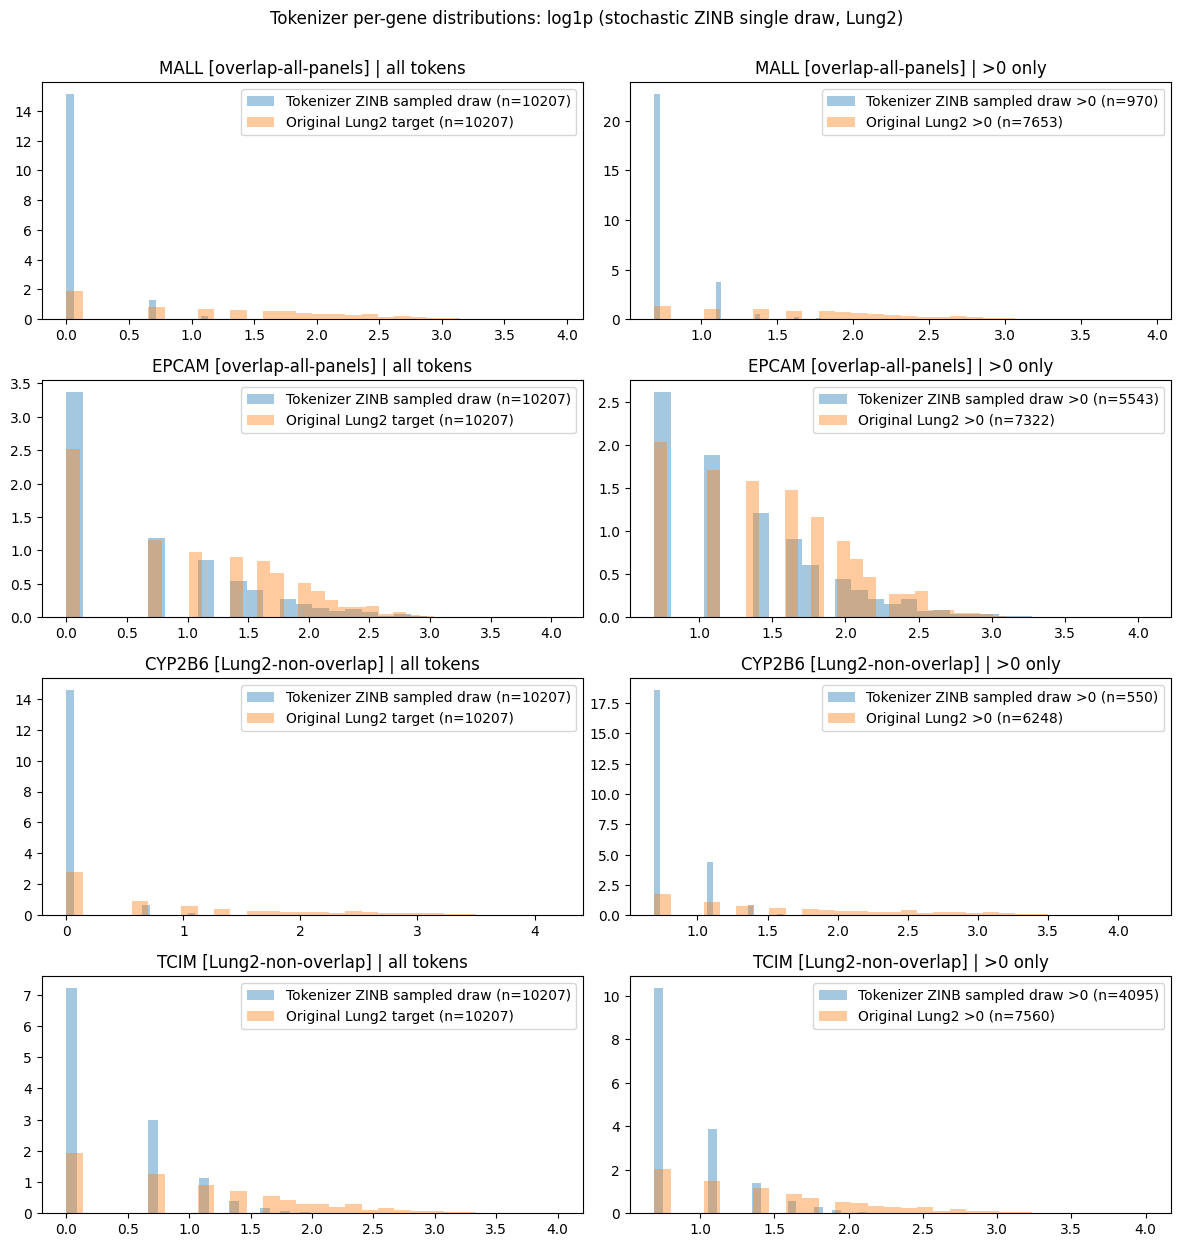

Per-gene summary (sampled tokenizer draw vs target):


,gene,group,mean_sampled,mean_target,detect_pct_sampled,detect_pct_target
0,MALL,overlap-all-panels,0.115313,4.611149,9.503282,74.977956
1,EPCAM,overlap-all-panels,1.952484,3.188106,54.305869,71.735084
2,CYP2B6,Lung2-non-overlap,0.068580,4.600960,5.388459,61.212893
3,TCIM,Lung2-non-overlap,0.666699,3.741452,40.119526,74.066817


In [ ]:
# Stochastic tokenizer reconstruction analysis (ZINB) for downsampled target panel -> original target panel
model_token_ae.eval()

# Set target panel key from TRAIN_PANELS / panel2id.
target_panel_name = "Lung2"
available_panels = sorted(panel2id.keys()) 

# Runtime controls
max_batches = 500  # set None for full test loader
eps = 1e-8

gene_names_vocab = np.asarray(id2gene).astype(str)
gene2id_local = {g: i for i, g in enumerate(gene_names_vocab)}


genes_for_plot, gene_group_label = _pick_genes_for_plot(target_panel_name)
print(
    f"Selected genes for plotting in {target_panel_name}: "
    f"overlap-all-panels={[g for g in genes_for_plot if gene_group_label[g] == 'overlap-all-panels']}, "
    f"{target_panel_name}-non-overlap={[g for g in genes_for_plot if gene_group_label[g] != 'overlap-all-panels']}"
)

wanted_ids = {gene2id_local[g]: g for g in genes_for_plot}
true_by_gene = {g: [] for g in genes_for_plot}
samp_by_gene = {g: [] for g in genes_for_plot}

n_target_cells_used = 0
with torch.no_grad():
    eval_bar = tqdm(test_loader_tok, desc=f"Tokenizer stochastic gene eval ({target_panel_name})", unit="batch")
    for b_idx, batch in enumerate(eval_bar):
        if max_batches is not None and b_idx >= max_batches:
            break

        if "panel_name" not in batch:
            continue

        gene_ids = batch["gene_ids"].to(device_token)
        x_vals = batch["x_vals"].to(device_token)  # raw counts, no log1p
        y_counts = batch["y_vals"].to(device_token).clamp_min(0.0)
        attn_mask = batch["attn_mask"].to(device_token)
        panel_id = batch["panel_id"].to(device_token)
        tissue_id = batch["tissue_id"].to(device_token)

        _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
            gene_ids=gene_ids,
            x_vals=x_vals,
            attn_mask=attn_mask,
            panel_id=panel_id,
            tissue_id=tissue_id,
        )
        stoch_counts = _zinb_single_draw(mu_logit, pi_logit, theta_unconstrained)

        ids_np = gene_ids.detach().cpu().numpy()
        mask_np = attn_mask.detach().cpu().numpy()
        y_np = y_counts.detach().cpu().numpy()
        s_np = stoch_counts.detach().cpu().numpy()

        for i in range(ids_np.shape[0]):
            if batch["panel_name"][i] != target_panel_name:
                continue
            n_target_cells_used += 1
            valid_idx = np.where(mask_np[i])[0]
            if valid_idx.size == 0:
                continue

            gids = ids_np[i, valid_idx]
            yv = y_np[i, valid_idx]
            sv = s_np[i, valid_idx]
            for gid, yt, st in zip(gids, yv, sv):
                gid = int(gid)
                if gid in wanted_ids:
                    gname = wanted_ids[gid]
                    true_by_gene[gname].append(float(yt))
                    samp_by_gene[gname].append(float(st))

# Summary metrics
a_true, a_samp = [], []
for g in genes_for_plot:
    if len(true_by_gene[g]) == 0:
        continue
    a_true.append(np.asarray(true_by_gene[g], dtype=np.float32))
    a_samp.append(np.asarray(samp_by_gene[g], dtype=np.float32))

if len(a_true) == 0:
    raise RuntimeError(f"No {target_panel_name} tokens collected for selected genes from tokenizer test loader.")

all_true = np.concatenate(a_true)
all_samp = np.concatenate(a_samp)
summary_tok_stoch = pd.DataFrame([
    {"metric": "mse_counts_selected_genes", "value": float(np.mean((all_samp - all_true) ** 2))},
    {"metric": "mse_log1p_selected_genes", "value": float(np.mean((np.log1p(all_samp) - np.log1p(all_true)) ** 2))},
    {"metric": "mae_detection_selected_genes", "value": float(np.mean(np.abs((all_samp > 0).astype(np.float32) - (all_true > 0).astype(np.float32))))},
    {"metric": "n_total_tokens_used", "value": float(all_true.size)},
    {"metric": "n_target_panel_cells_used", "value": float(n_target_cells_used)},
])

print(
    f"Tokenizer stochastic reconstruction summary (downsampled {target_panel_name} -> original {target_panel_name}; "
    f"single-draw ZINB sampling per token):"
)
display(summary_tok_stoch)

# Plot distributions
n_rows = len(genes_for_plot)
fig, axs = plt.subplots(n_rows, 2, figsize=(12, 3.1 * n_rows), squeeze=False)

rows = []
for i, g in enumerate(genes_for_plot):
    x_true = np.asarray(true_by_gene[g], dtype=np.float32)
    x_samp = np.asarray(samp_by_gene[g], dtype=np.float32)
    if x_true.size == 0 or x_samp.size == 0:
        continue

    xt_all = np.log1p(np.clip(x_true, 0.0, None))
    xs_all = np.log1p(np.clip(x_samp, 0.0, None))
    xt_pos = xt_all[x_true > 0]
    xs_pos = xs_all[x_samp > 0]
    group_txt = gene_group_label.get(g, "")

    axL = axs[i, 0]
    axL.hist(xs_all, bins=30, density=True, alpha=0.4, label=f"Tokenizer ZINB sampled draw (n={len(xs_all)})")
    axL.hist(xt_all, bins=30, density=True, alpha=0.4, label=f"Original {target_panel_name} target (n={len(xt_all)})")
    axL.set_title(f"{g} [{group_txt}] | all tokens")
    axL.legend(frameon=True)

    axR = axs[i, 1]
    if xs_pos.size > 0:
        axR.hist(xs_pos, bins=30, density=True, alpha=0.4, label=f"Tokenizer ZINB sampled draw >0 (n={len(xs_pos)})")
    if xt_pos.size > 0:
        axR.hist(xt_pos, bins=30, density=True, alpha=0.4, label=f"Original {target_panel_name} >0 (n={len(xt_pos)})")
    axR.set_title(f"{g} [{group_txt}] | >0 only")
    axR.legend(frameon=True)

    rows.append({
        "gene": g,
        "group": group_txt,
        "mean_sampled": float(x_samp.mean()),
        "mean_target": float(x_true.mean()),
        "detect_pct_sampled": float(100.0 * (x_samp > 0).mean()),
        "detect_pct_target": float(100.0 * (x_true > 0).mean()),
    })

fig.suptitle(f"Tokenizer per-gene distributions: log1p (stochastic ZINB single draw, {target_panel_name})", y=1.002)
plt.tight_layout()
plt.show()

print("Per-gene summary (sampled tokenizer draw vs target):")
display(pd.DataFrame(rows))

### Stochastic Reconstruction: (5K -> V1)
Here we do the reconstruction of the 5K panel and and compare it to subsequent V1 sample
`NOTE`: In this current example, V1 was in the training set. 

Important parameter:
- `batch_size`: To prevent memory issues, we can set the batch size
- `restrict_genes`: To help with memory, we can limit reconstruction to only specific genes 

What the function does:
1. AnnData panel --> tokenized model input
2. tokenized model input --> reconstructed counts
3. reconstructed counts --> new AnnData panel 

In [ ]:
def reconstruct_panel_with_token_ae(adata_panel, context_panel_name="V1", batch_size=64, restrict_genes=None):
    """
    Reconstruct a panel through the trained token AE.
    Uses context panel/tissue IDs only for conditioning embeddings.
    Optionally reconstructs only a subset of genes to reduce memory use.
    """
    # We have to supply the context panel/tissue, so we can supply its embeddings
    if context_panel_name not in panel2id:
        raise ValueError(f"context_panel_name='{context_panel_name}' not found in panel2id: {list(panel2id.keys())}")

    context_tissue_name = PANEL_TO_TISSUE.get(context_panel_name)
    if context_tissue_name is None or context_tissue_name not in tissue2id:
        context_tissue_name = list(tissue2id.keys())[0]

    # Decide which genes to reconstruct
    panel_genes = pd.Index(adata_panel.var_names.astype(str))
    vocab_genes = pd.Index(gene2id.keys())
    keep_genes = panel_genes.intersection(vocab_genes)
    if restrict_genes is not None:
        keep_genes = keep_genes.intersection(pd.Index(restrict_genes).astype(str))
    if len(keep_genes) == 0:
        raise ValueError("No genes from this panel are present in token model vocabulary after filtering.")

    # Set up data for reconstruction (only the genes we will reconstruct)
    X_view = adata_panel[:, keep_genes].X
    n_cells = adata_panel.n_obs
    n_genes_keep = len(keep_genes)

    # Map gene names to IDs for the model.
    gene_ids_np = np.array([gene2id[g] for g in keep_genes], dtype=np.int64)
    panel_id_val = int(panel2id[context_panel_name])
    tissue_id_val = int(tissue2id[context_tissue_name])

    model_token_ae.eval()
    recon_counts = np.empty((n_cells, n_genes_keep), dtype=np.float32)
    eps = 1e-8
    use_zinb_sampling = hasattr(model_token_ae, "forward_with_params") # otherwise it will just do a deterministic decodoe 
    zero_count = 0

    # We perform the reconstruction in batches 
    with torch.no_grad():
        for s in range(0, n_cells, batch_size):
            e = min(s + batch_size, n_cells)
            xb_raw = X_view[s:e]
            if sp.issparse(xb_raw):
                xb_np = xb_raw.toarray().astype(np.float32, copy=False)
            else:
                xb_np = np.asarray(xb_raw, dtype=np.float32)

            np.clip(xb_np, 0.0, None, out=xb_np)
            xb = torch.from_numpy(xb_np).to(device_token)

            b = xb.shape[0]
            l = xb.shape[1]

            gene_ids = torch.from_numpy(np.broadcast_to(gene_ids_np, (b, l))).to(device_token)
            attn_mask = torch.ones((b, l), dtype=torch.bool, device=device_token)
            panel_id = torch.full((b,), panel_id_val, dtype=torch.long, device=device_token)
            tissue_id = torch.full((b,), tissue_id_val, dtype=torch.long, device=device_token)

            if use_zinb_sampling:
                _, _, mu_logit, pi_logit, theta_unconstrained = model_token_ae.forward_with_params(
                    gene_ids=gene_ids,
                    x_vals=xb,
                    attn_mask=attn_mask,
                    panel_id=panel_id,
                    tissue_id=tissue_id,
                )
                mu = torch.nn.functional.softplus(mu_logit) + eps
                pi = torch.sigmoid(pi_logit)
                theta = torch.nn.functional.softplus(theta_unconstrained) + eps

                gamma_rate = theta / (mu + eps)
                gamma_dist = torch.distributions.Gamma(concentration=theta, rate=gamma_rate)
                lam = gamma_dist.sample()
                nb_sample = torch.poisson(lam)
                drop_mask = torch.bernoulli(pi).bool()
                recon_counts_batch = nb_sample.masked_fill(drop_mask, 0.0).cpu().numpy().astype(np.float32, copy=False)
            else:
                recon_log, _ = model_token_ae(
                    gene_ids=gene_ids,
                    x_vals=xb,
                    attn_mask=attn_mask,
                    panel_id=panel_id,
                    tissue_id=tissue_id,
                )
                recon_counts_batch = np.expm1(recon_log.cpu().numpy())
                recon_counts_batch = np.clip(recon_counts_batch, 0.0, None).astype(np.float32, copy=False)

            recon_counts[s:e] = recon_counts_batch
            zero_count += int((recon_counts_batch == 0.0).sum())

    frac_zero = zero_count / float(recon_counts.size)
    mode_label = "stochastic ZINB sample" if use_zinb_sampling else "deterministic decode"
    print(f"Reconstruction mode: {mode_label}; fraction exact zeros={100.0 * frac_zero:.2f}%")

    adata_recon = type(adata_panel)(
        X=recon_counts,
        obs=adata_panel.obs.copy(),
        var=pd.DataFrame(index=keep_genes.copy()),
    )
    
    # Keep spatial so downstream plotting works.
    if hasattr(adata_panel, "obsm") and len(getattr(adata_panel, "obsm", {})) > 0:
        for k in adata_panel.obsm.keys():
            adata_recon.obsm[k] = adata_panel.obsm[k].copy()
    if hasattr(adata_panel, "uns") and len(getattr(adata_panel, "uns", {})) > 0:
        for k, v in adata_panel.uns.items():
            adata_recon.uns[k] = v
    return adata_recon

Reconstruction mode: stochastic ZINB sample; fraction exact zeros=80.39%
Genes shared by both versions: 196
Genes plotted: ['EPCAM', 'STEAP4', 'CDH1', 'MUC1']


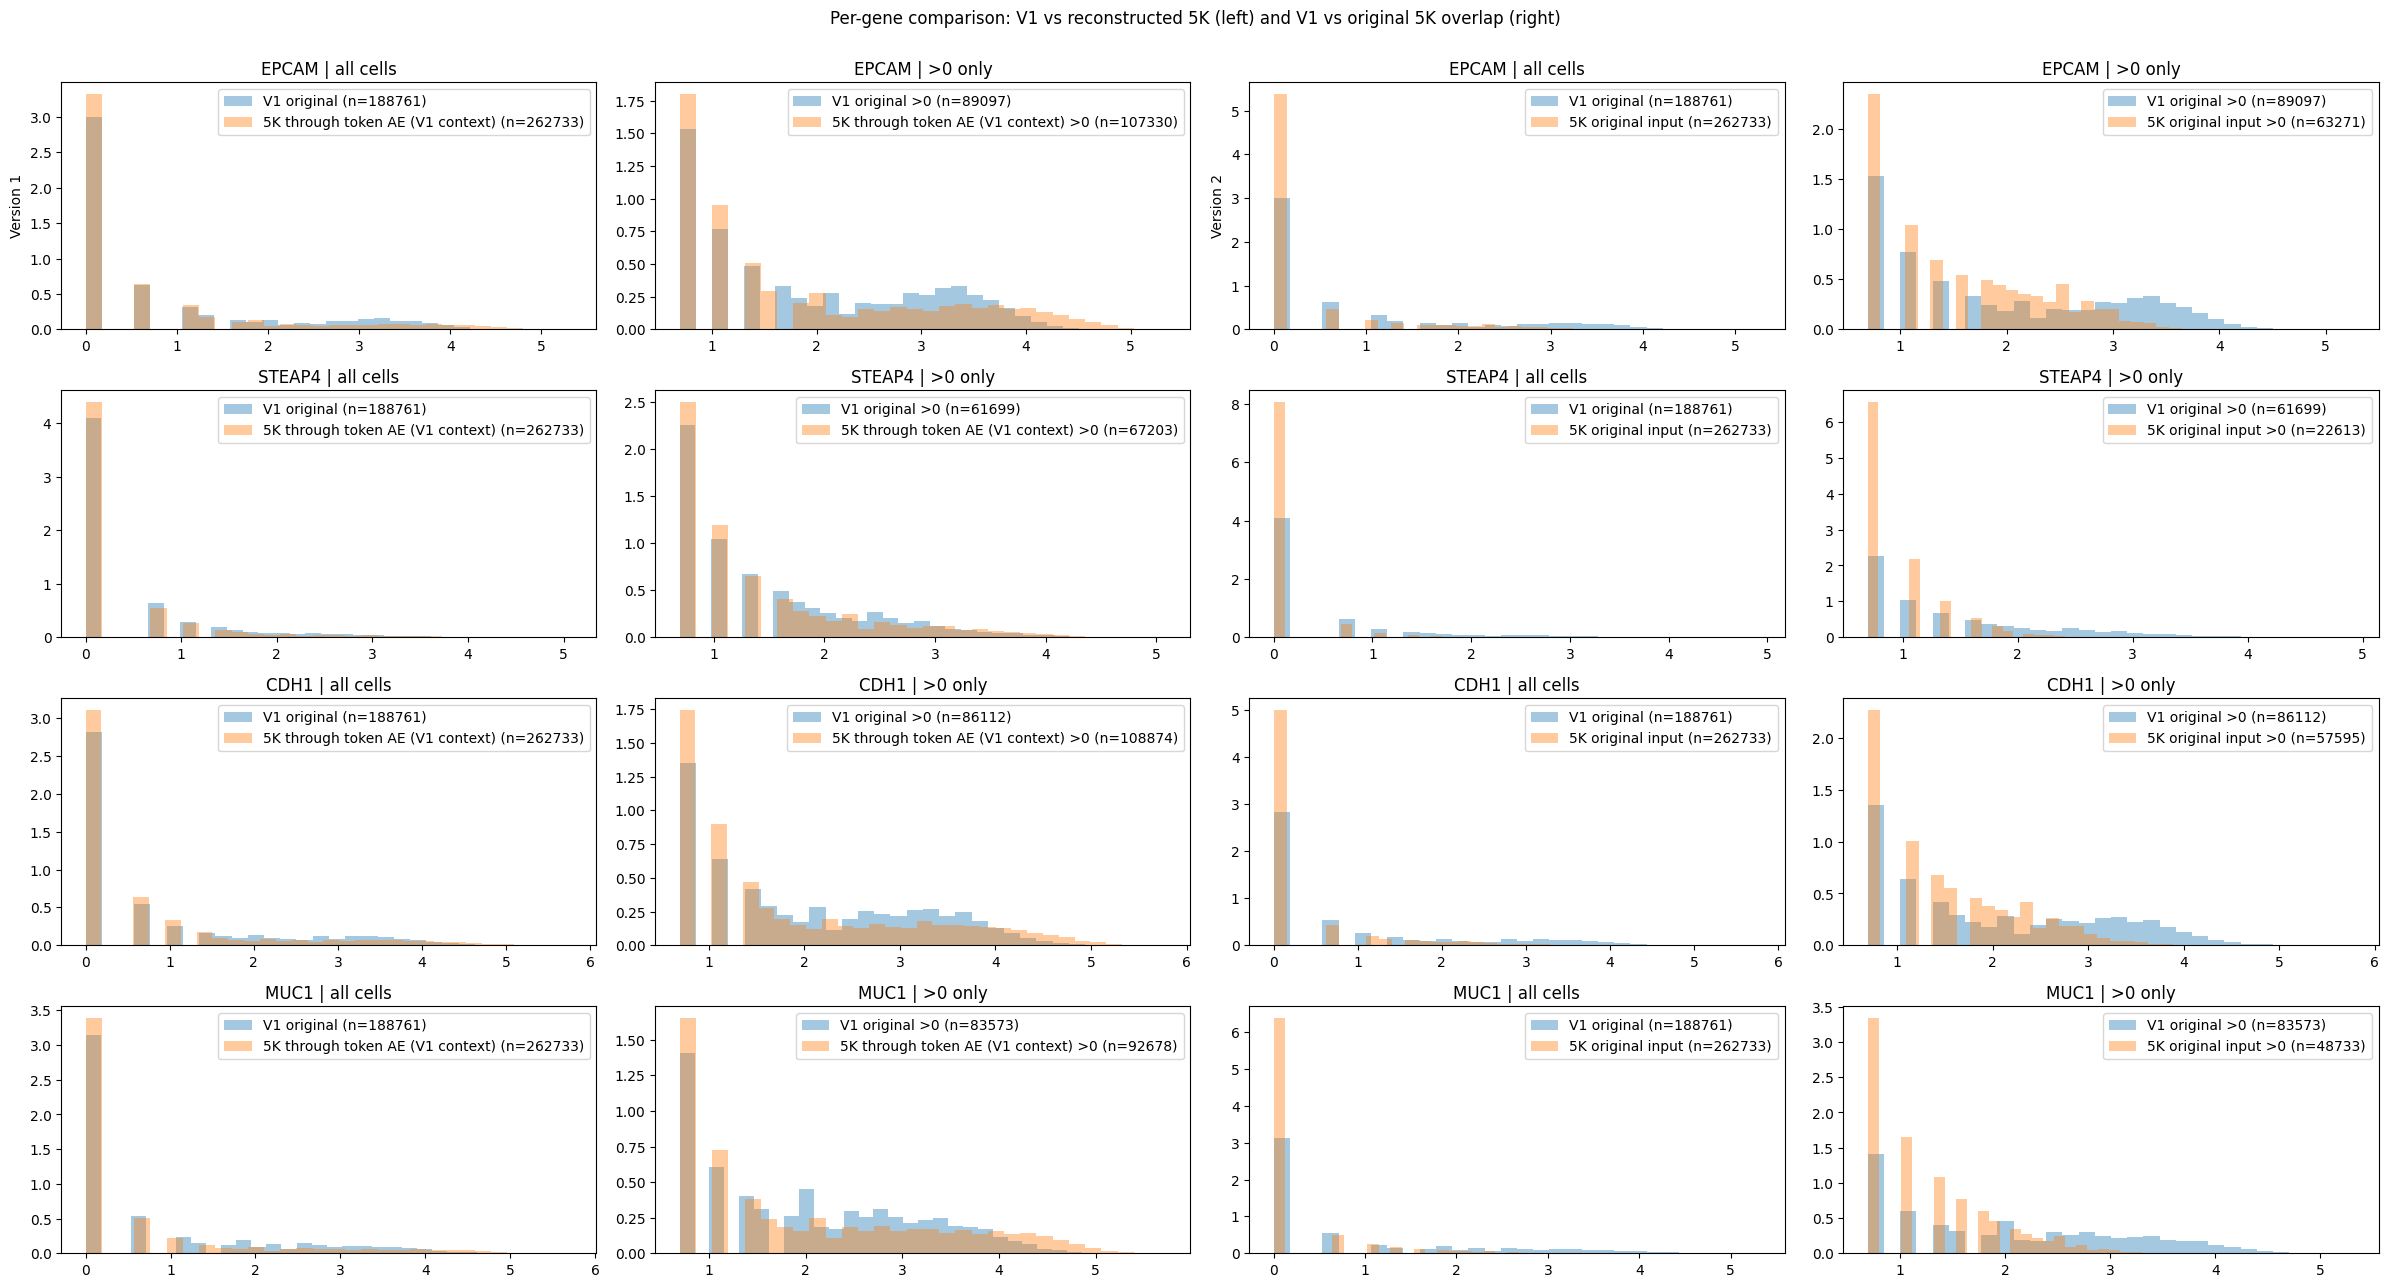

In [72]:
# Set source/target panels for cross-panel evaluation.
source_panel_name = "5K"    # The panel we want to reconstruct 
target_panel_name = "V1"    # The panel we want to use as target
context_panel_name = "V1"   # The panel whose panel & tissue embedding will be used as context for reconstruction 

if source_panel_name not in adatas:
    raise ValueError(f"Source panel '{source_panel_name}' not found in adatas. Available: {sorted(adatas.keys())}")
if target_panel_name not in adatas:
    raise ValueError(f"Target panel '{target_panel_name}' not found in adatas. Available: {sorted(adatas.keys())}")

adata_src = adatas[source_panel_name]      # Original 5K input panel
adata_tgt = adatas[target_panel_name]      # Original V1 target panel

# Reconstruct source panel through the trained token AE using V1 context embeddings.
adata_src_recon = reconstruct_panel_with_token_ae(
    adata_panel=adata_src,
    context_panel_name=context_panel_name,
    batch_size=128,
)

# Overlap for reconstructed-vs-target and original-vs-target comparisons.
common_recon = pd.Index(adata_tgt.var_names.astype(str)).intersection(pd.Index(adata_src_recon.var_names.astype(str)))
common_orig = pd.Index(adata_tgt.var_names.astype(str)).intersection(pd.Index(adata_src.var_names.astype(str)))
common_all = common_recon.intersection(common_orig)
if len(common_all) == 0:
    raise ValueError("No common genes available for both comparison versions.")

# Reuse the same gene-selection helper when available.
try:
    genes_for_plot, gene_group_label = _pick_genes_for_plot(target_panel_name)
    genes_for_plot = [g for g in genes_for_plot if g in set(common_all)]
except Exception:
    genes_for_plot = []

if len(genes_for_plot) == 0:
    x_tgt = _to_dense_float32(adata_tgt[:, common_all].X)
    mean_tgt = x_tgt.mean(axis=0)
    top_idx = np.argsort(-mean_tgt)[:6]
    genes_for_plot = adata_tgt[:, common_all].var_names[top_idx].astype(str).tolist()

print(f"Genes shared by both versions: {len(common_all)}")
print(f"Genes plotted: {genes_for_plot}")

# Build aligned AnnData views for both versions.
adata_tgt_view = adata_tgt[:, genes_for_plot].copy()
adata_src_recon_view = adata_src_recon[:, genes_for_plot].copy()
adata_src_orig_view = adata_src[:, genes_for_plot].copy()


def _plot_pair(axL, axR, adata_left, adata_right, gene, left_label, right_label, bins=30, density=True):
    j1 = adata_left.var_names.get_loc(gene)
    j2 = adata_right.var_names.get_loc(gene)

    c1 = _col_dense(adata_left.X, j1)
    c2 = _col_dense(adata_right.X, j2)

    x1_all = np.log1p(c1)
    x2_all = np.log1p(c2)

    x1_pos = x1_all[c1 > 0]
    x2_pos = x2_all[c2 > 0]

    # Left axis: all cells
    axL.hist(x1_all, bins=bins, density=density, alpha=0.4, label=f"{left_label} (n={len(x1_all)})")
    axL.hist(x2_all, bins=bins, density=density, alpha=0.4, label=f"{right_label} (n={len(x2_all)})")
    axL.set_title(f"{gene} | all cells")
    axL.legend(frameon=True)

    # Right axis: positives only
    axR.hist(x1_pos, bins=bins, density=density, alpha=0.4, label=f"{left_label} >0 (n={len(x1_pos)})")
    axR.hist(x2_pos, bins=bins, density=density, alpha=0.4, label=f"{right_label} >0 (n={len(x2_pos)})")
    axR.set_title(f"{gene} | >0 only")
    axR.legend(frameon=True)


n = len(genes_for_plot)
fig, axs = plt.subplots(n, 4, figsize=(24, 3.2 * n), squeeze=False)

for i, gene in enumerate(genes_for_plot):
    # Left: Original V1 vs reconstructed 5K through token AE
    _plot_pair(
        axs[i, 0], axs[i, 1],
        adata_tgt_view,
        adata_src_recon_view,
        gene,
        left_label=f"{target_panel_name} original",
        right_label=f"{source_panel_name} through token AE ({context_panel_name} context)",
        bins=30,
        density=True,
    )

    # Right: overlap of original 5K input vs original V1
    _plot_pair(
        axs[i, 2], axs[i, 3],
        adata_tgt_view,
        adata_src_orig_view,
        gene,
        left_label=f"{target_panel_name} original",
        right_label=f"{source_panel_name} original input",
        bins=30,
        density=True,
    )

# Column headers for clarity
axs[0, 0].set_ylabel("Version 1")
axs[0, 2].set_ylabel("Version 2")
fig.suptitle(
    "Per-gene comparison: V1 vs reconstructed 5K (left) and V1 vs original 5K overlap (right)",
    y=1.002,
)
plt.tight_layout()
plt.show()

## Spatial Plots 
Between the overlapping genes 

In [40]:
def _ensure_spatial_coords(adata):
    if "spatial" in adata.obsm:
        return
    candidate_pairs = [
        ("x_centroid", "y_centroid"),
        ("x", "y"),
        ("center_x", "center_y"),
        ("centroid_x", "centroid_y"),
        ("global_x", "global_y"),
    ]
    pair = next(
        ((x, y) for x, y in candidate_pairs if x in adata.obs.columns and y in adata.obs.columns),
        None,
    )
    if pair is None:
        raise KeyError(
            "No spatial coordinates found. Expected adata.obsm['spatial'] or one of: "
            f"{candidate_pairs}."
        )
    adata.obsm["spatial"] = adata.obs[[pair[0], pair[1]]].to_numpy()

Overlap genes used for spatial plotting: 196


C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\3699020702.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\3699020702.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\ntpar\AppData\Local\Temp\ipykernel_38576\3699020702.py:44: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


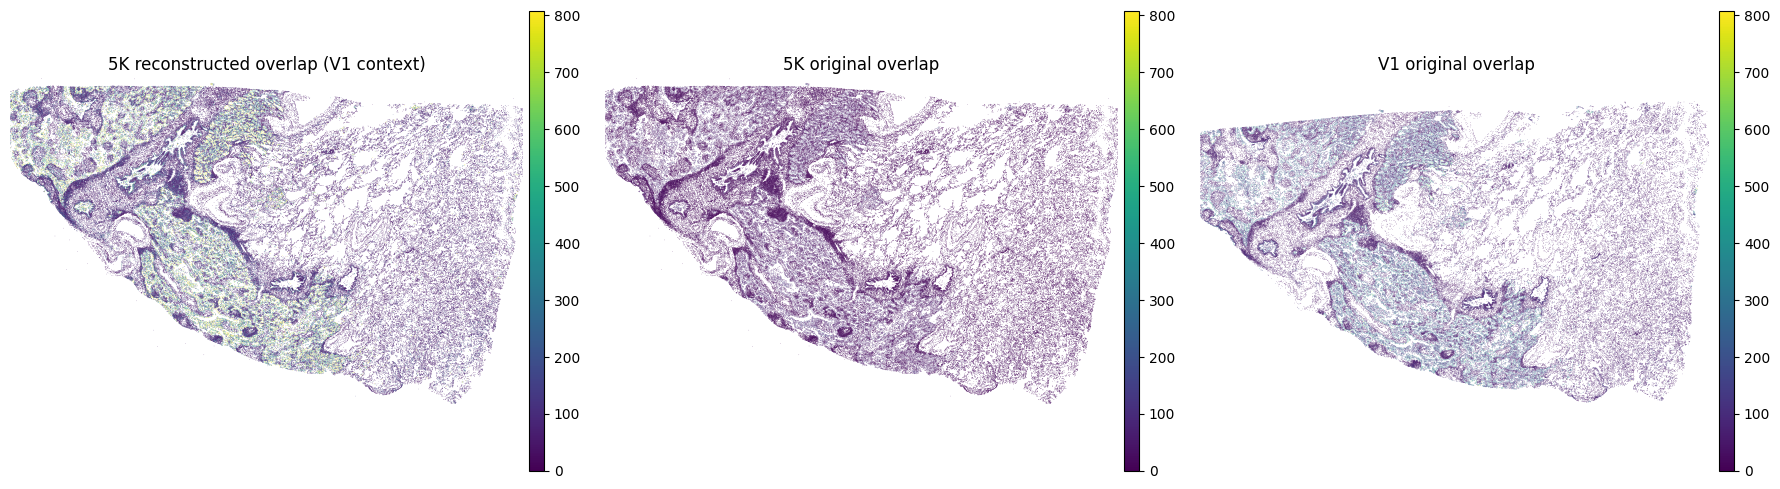

In [ ]:
# Overlap-only spatial plots (shared genes across reconstructed/source/target)
overlap_spatial_genes = (
    pd.Index(adata_src_recon.var_names.astype(str))
    .intersection(pd.Index(adata_src.var_names.astype(str)))
    .intersection(pd.Index(adata_tgt.var_names.astype(str)))
)


adata_src_recon_ov = adata_src_recon[:, overlap_spatial_genes].copy()
adata_src_ov = adata_src[:, overlap_spatial_genes].copy()
adata_tgt_ov = adata_tgt[:, overlap_spatial_genes].copy()

plot_adatas_ov = [adata_src_recon_ov, adata_src_ov, adata_tgt_ov]
plot_titles_ov = [
    f"{source_panel_name} reconstructed overlap ({context_panel_name} context)",
    f"{source_panel_name} original overlap",
    f"{target_panel_name} original overlap",
]

for adata in plot_adatas_ov:
    _ensure_spatial_coords(adata)

for adata in plot_adatas_ov:
    Xp = adata.X
    if sp.issparse(Xp):
        adata.obs["__plot_total_counts_overlap"] = np.ravel(Xp.sum(axis=1)).astype(float)
    else:
        adata.obs["__plot_total_counts_overlap"] = np.asarray(Xp).sum(axis=1).astype(float)

shared_color_key_ov = "__plot_total_counts_overlap"

xy_all_ov = np.vstack([np.asarray(adata.obsm["spatial"], dtype=float) for adata in plot_adatas_ov])
shared_xlim_ov = (float(np.nanmin(xy_all_ov[:, 0])), float(np.nanmax(xy_all_ov[:, 0])))
shared_ylim_ov = (float(np.nanmin(xy_all_ov[:, 1])), float(np.nanmax(xy_all_ov[:, 1])))

c_all_ov = np.concatenate([adata.obs[shared_color_key_ov].to_numpy(dtype=float) for adata in plot_adatas_ov])
shared_vrange_ov = (float(np.nanmin(c_all_ov)), float(np.nanpercentile(c_all_ov, 99.0)))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, adata, title in zip(axs, plot_adatas_ov, plot_titles_ov):
    sc.pl.spatial(
        adata,
        ax=ax,
        color=shared_color_key_ov,
        vmin=shared_vrange_ov[0],
        vmax=shared_vrange_ov[1],
        spot_size=10,
        frameon=False,
        show=False,
    )
    ax.set_xlim(shared_xlim_ov)
    ax.set_ylim(shared_ylim_ov)
    ax.set_aspect("equal")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Standardized plots

In [1]:
# Exact-style subplot: y=x line, linear fit, n genes, Pearson r, and fit equation
def plot_exact_scatter_with_fit(
    x,
    y,
    title,
    x_label,
    y_label,
    color="#E68613",
    figsize=(7, 6),
    point_size=18,
    alpha=0.65,
    text_loc=(0.02, 0.98),
    line_pad=0.02,
    ax=None,
 ):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    n_genes = x.size
    if n_genes < 2:
        raise ValueError("Need at least 2 valid points to fit a line.")

    slope, intercept = np.polyfit(x, y, 1)
    pearson_r = float(np.corrcoef(x, y)[0, 1])

    line_max = float(max(x.max(), y.max())) * (1.0 + line_pad) if n_genes > 0 else 1.0
    line_x = np.array([0.0, line_max], dtype=np.float64)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True

    ax.scatter(x, y, s=point_size, alpha=alpha, color=color)
    ax.plot(line_x, line_x, "k--", linewidth=1.2, alpha=0.8, label="y = x")
    ax.plot(line_x, slope * line_x + intercept, color=color, linewidth=1.6, alpha=0.95, label="fit")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

    ax.text(
        text_loc[0], text_loc[1],
        f"genes={n_genes}\nPearson r={pearson_r:.3f}\nfit: y={slope:.3f}x+{intercept:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.set_xlim(-0.01 * line_max, line_max)
    ax.set_ylim(-0.01 * line_max, line_max)

    if created_fig:
        plt.tight_layout()
        plt.show()

    return {
        "n_genes": int(n_genes),
        "pearson_r": pearson_r,
        "slope": float(slope),
        "intercept": float(intercept),
        "line_max": line_max,
    }

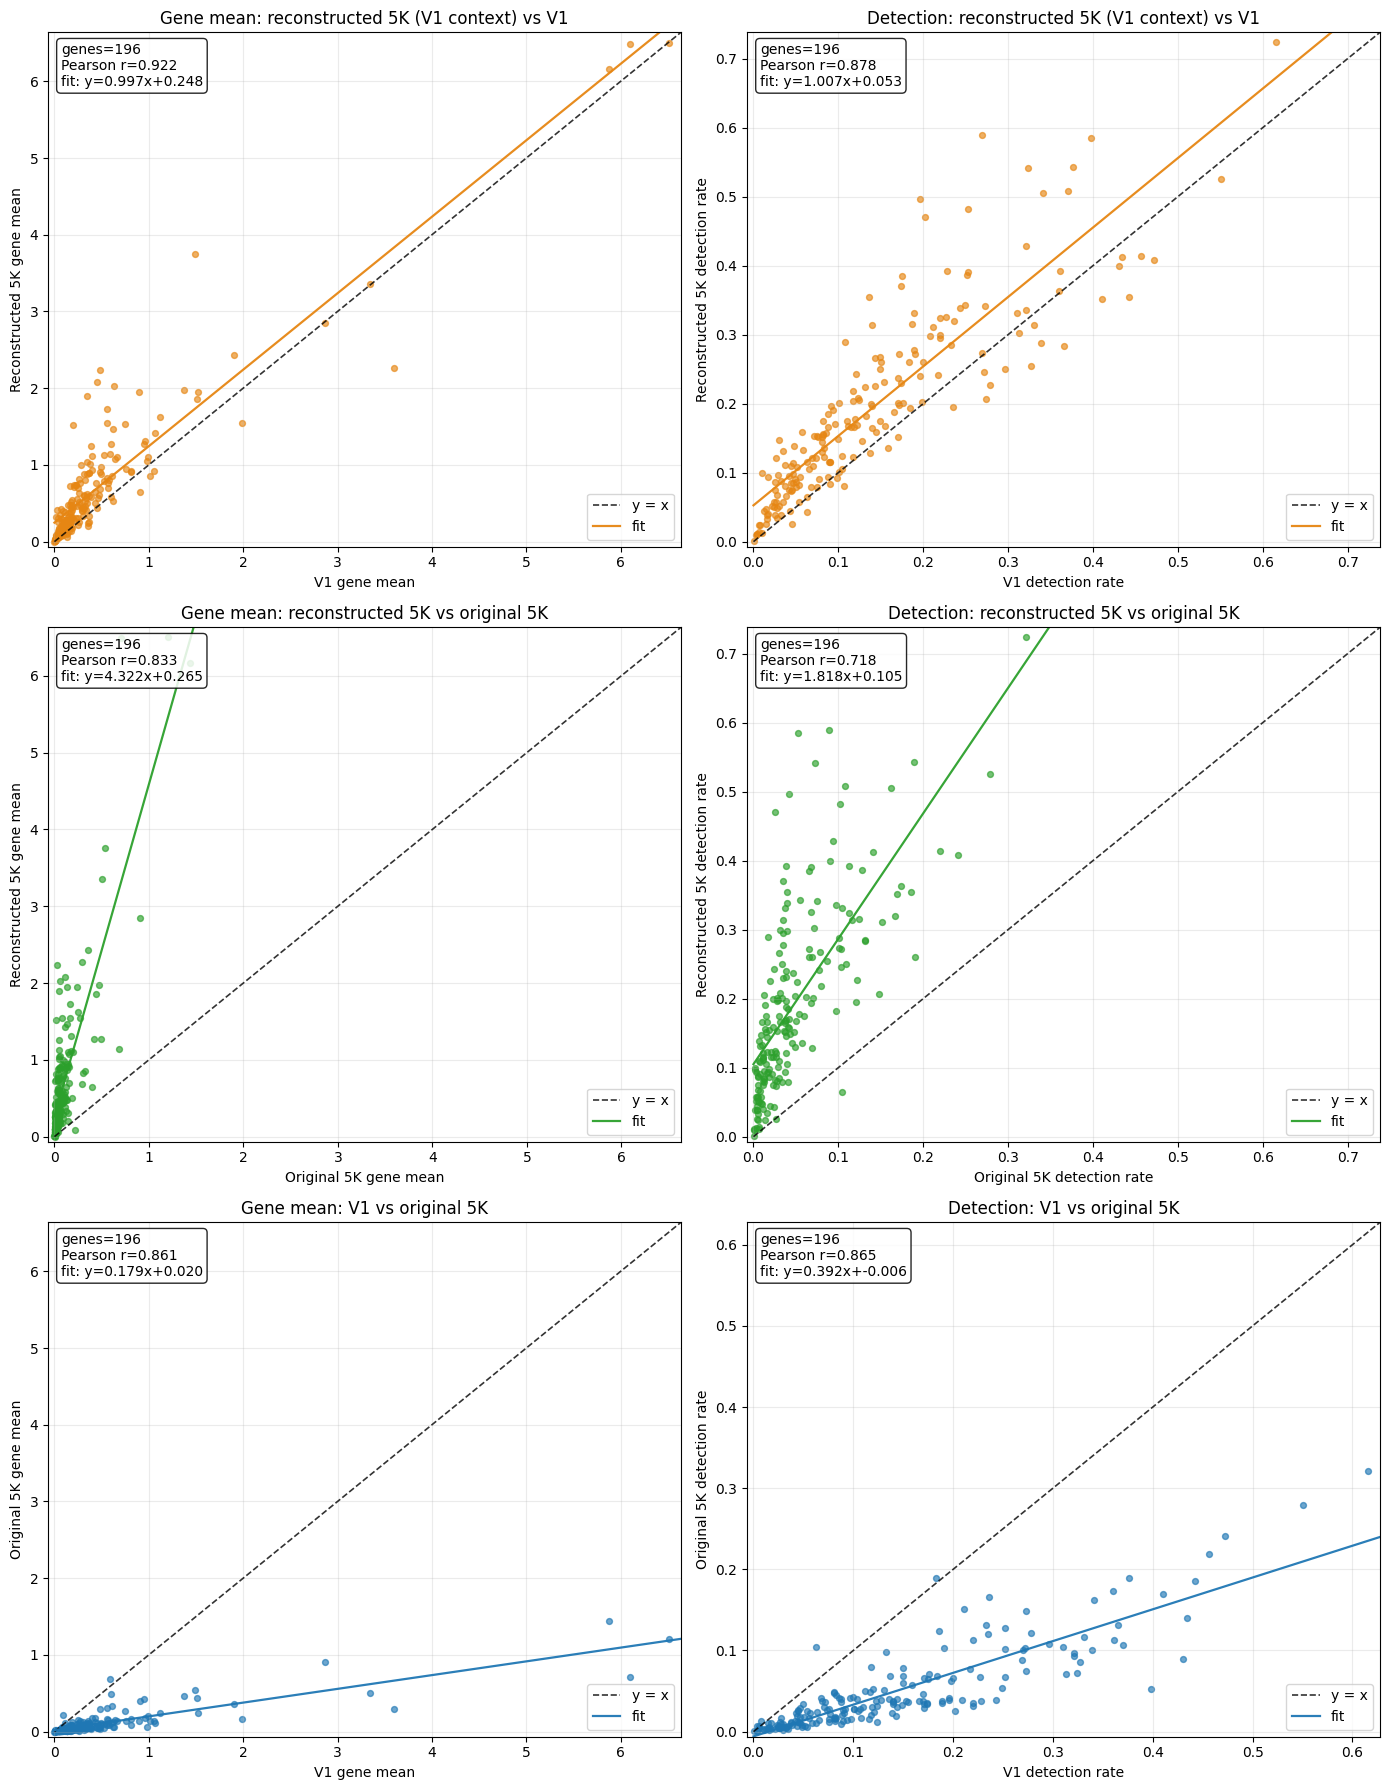

Used 196 overlap genes for standardized pairwise plots: reconstructed 5K (V1 context), original 5K, original V1


In [ ]:
# Shared genes across all three objects
common_genes = (
    pd.Index(adata_src_recon.var_names.astype(str))
    .intersection(pd.Index(adata_src.var_names.astype(str)))
    .intersection(pd.Index(adata_tgt.var_names.astype(str)))
)

adata_src_recon_common = adata_src_recon[:, common_genes]
adata_src_common = adata_src[:, common_genes]
adata_tgt_common = adata_tgt[:, common_genes]

def _mean_and_detect(adata):
    Xd = _to_dense_float32(adata.X)
    mean_expr = Xd.mean(axis=0)
    detect_rate = (Xd > 0).mean(axis=0)
    return mean_expr, detect_rate

mean_recon, det_recon = _mean_and_detect(adata_src_recon_common)
mean_5k, det_5k = _mean_and_detect(adata_src_common)
mean_v1, det_v1 = _mean_and_detect(adata_tgt_common)

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Reconstructed vs V1 lung
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_recon,
    title=f"Gene mean: reconstructed {source_panel_name} ({context_panel_name} context) vs {target_panel_name}",
    x_label=f"{target_panel_name} gene mean",
    y_label=f"Reconstructed {source_panel_name} gene mean",
    color="#E68613",
    ax=axes[0, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_recon,
    title=f"Detection: reconstructed {source_panel_name} ({context_panel_name} context) vs {target_panel_name}",
    x_label=f"{target_panel_name} detection rate",
    y_label=f"Reconstructed {source_panel_name} detection rate",
    color="#E68613",
    ax=axes[0, 1],
)

# Reconstructed vs original 5K lung
plot_exact_scatter_with_fit(
    x=mean_5k, y=mean_recon,
    title=f"Gene mean: reconstructed {source_panel_name} vs original {source_panel_name}",
    x_label=f"Original {source_panel_name} gene mean",
    y_label=f"Reconstructed {source_panel_name} gene mean",
    color="#2ca02c",
    ax=axes[1, 0],
)
plot_exact_scatter_with_fit(
    x=det_5k, y=det_recon,
    title=f"Detection: reconstructed {source_panel_name} vs original {source_panel_name}",
    x_label=f"Original {source_panel_name} detection rate",
    y_label=f"Reconstructed {source_panel_name} detection rate",
    color="#2ca02c",
    ax=axes[1, 1],
)

# V1 lung vs original 5K lung
plot_exact_scatter_with_fit(
    x=mean_v1, y=mean_5k,
    title=f"Gene mean: {target_panel_name} vs original {source_panel_name}",
    x_label=f"{target_panel_name} gene mean",
    y_label=f"Original {source_panel_name} gene mean",
    color="#1f77b4",
    ax=axes[2, 0],
)
plot_exact_scatter_with_fit(
    x=det_v1, y=det_5k,
    title=f"Detection: {target_panel_name} vs original {source_panel_name}",
    x_label=f"{target_panel_name} detection rate",
    y_label=f"Original {source_panel_name} detection rate",
    color="#1f77b4",
    ax=axes[2, 1],
)

plt.tight_layout()
plt.show()

print(
    f"Used {len(common_genes)} overlap genes for standardized pairwise plots: "
    f"reconstructed {source_panel_name} ({context_panel_name} context), original {source_panel_name}, original {target_panel_name}"
)